[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/03_gradient_descent_and_convergence/first_principles.ipynb)

# Module 03 — Gradient Descent and Convergence

## 1. Why This Module Exists

Almost every large-scale model fitted today is fitted by repeatedly stepping downhill. The rule

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha \nabla f(\mathbf{x}_k)
$$

costs one gradient and $O(n)$ arithmetic per step, stores a handful of vectors, and never forms
a matrix. That is why it survives at $n = 10^{11}$, where any method touching a Hessian does not.

The question this module answers is not *does it work* but **how fast, and under exactly which
hypotheses**. The answer is a short, complete rate table controlled by two scalars: an upper
curvature bound $L$ and a lower curvature bound $\mu$. Nothing in the table depends on the
dimension $n$. Everything in it depends on the ratio $\kappa = L/\mu$.

Getting the hypotheses right is not pedantry, it is money. A step size above $2/L$ diverges; a
step size well below it wastes compute. A practitioner who believes "smaller learning rate is
always safer" pays a factor of $\kappa$ in wall-clock time. A practitioner who believes
"non-convex means no guarantee" misses that $O(1/\sqrt{k})$ convergence to stationarity needs no
convexity at all, and that the Polyak-Lojasiewicz condition buys a full linear rate on landscapes
that are provably non-convex.

The module ends where first-order optimization ends: at Nesterov's accelerated method, whose
$O(1/k^2)$ rate is proved here in full and cannot be improved by any method that only ever looks
at gradients.

## 2. Intuition

### 2.1 A landscape probed only locally

Stand on a foggy mountainside. You can feel the height under your feet and the slope, nothing
else. Every first-order method is a policy for turning that local data into a step.

The first-order Taylor expansion says that moving a short distance $\alpha$ along a unit
direction $\mathbf{d}$ changes the height by approximately $\alpha \nabla f(\mathbf{x})^T \mathbf{d}$.
That inner product is most negative when $\mathbf{d}$ points exactly opposite the gradient — this
is Theorem 4.1, proved in Proof 5.1. Hence the negative gradient, and hence Definition 3.1.

Two cautions are already visible in the fog. First, "steepest" is measured in a norm; change the
norm and the steepest direction changes, which is the entire content of preconditioning. Second,
a slope says nothing about *how far* the slope stays valid — that is what the curvature bounds
supply.

### 2.2 The two constants that govern everything

- **Smoothness $L$** (upper curvature): the gradient cannot rotate or grow faster than $L$ per
  unit of distance. It tells us how far the linear model can be trusted, and therefore how large
  a step is safe.
- **Strong convexity $\mu$** (lower curvature): the surface bends upward at least this fast in
  every direction, so the landscape is a genuine bowl and a small gradient certifies proximity
  to the bottom.

Their ratio $\kappa = L/\mu \ge 1$ is the **condition number**. At $\kappa = 1$ the level sets are
spheres, the gradient points straight at the minimizer, and one well-chosen step finishes the job.
At $\kappa \gg 1$ the level sets are long thin ellipsoids, whose aspect ratio is $\sqrt{\kappa}$;
a single step size is then simultaneously too large for the stiff direction, so the iterates
oscillate across the valley, and too small for the flat direction, so they crawl along it. This is
the **zig-zag**, and it is the phenomenon every rate below quantifies.

### 2.3 The continuous-time picture

Shrink the step to zero and the iterates trace the **gradient flow**
$\dot{\mathbf{x}} = -\nabla f(\mathbf{x})$, along which

$$
\frac{d}{dt}f(\mathbf{x}(t)) = -\lVert \nabla f(\mathbf{x}(t))\rVert^2 \le 0
$$

so the continuous dynamics *always* descend, with no step size to get wrong. Gradient descent is
the forward Euler discretization of that flow, and the threshold $\alpha \lt 2/L$ derived later
is exactly forward Euler's stability limit. Momentum discretizes a *second-order* ODE instead — a
ball with inertia rolling under friction — which is why it both goes faster and rings.

The figure below draws the whole story of Section 2.2 on the anisotropic bowl
$f(x, y) = x^2 + 10y^2$ ($\mu = 2$, $L = 20$, $\kappa = 10$): elliptical level sets, a large step
that zig-zags across the valley, and a small step that crawls along it.

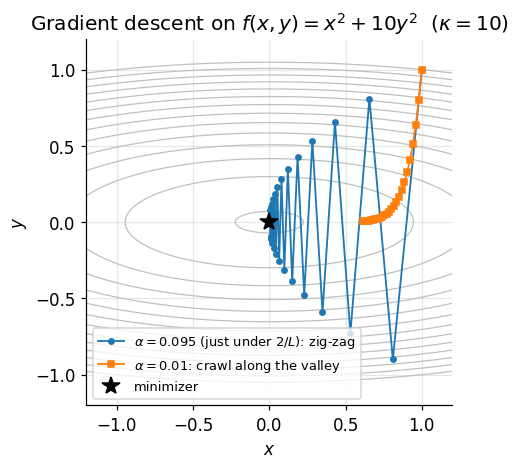

kappa = 10.0,  stability limit 2/L = 0.100
f after 24 steps: alpha=0.095 -> 6.3667e-02,  alpha=0.01 -> 3.7941e-01


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import linalg as sla
from scipy import optimize as sopt


def gd_path(grad, x0, alpha, n_steps):
    """Gradient-descent trajectory as an (n_steps + 1, n) array."""
    xs = [np.asarray(x0, dtype=float)]
    for _ in range(n_steps):
        xs.append(xs[-1] - alpha * grad(xs[-1]))
    return np.array(xs)


# f(x, y) = x^2 + 10 y^2  ->  Hessian diag(2, 20), mu = 2, L = 20, kappa = 10
f_bowl = lambda p: p[0] ** 2 + 10 * p[1] ** 2
g_bowl = lambda p: np.array([2 * p[0], 20 * p[1]])
mu_bowl, L_bowl = 2.0, 20.0

path_big = gd_path(g_bowl, [1.0, 1.0], 0.095, 24)     # just under 2/L = 0.1: zig-zag
path_small = gd_path(g_bowl, [1.0, 1.0], 0.01, 24)    # far below 2/L: crawl

gx, gy = np.meshgrid(np.linspace(-1.2, 1.2, 400), np.linspace(-1.2, 1.2, 400))
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.contour(gx, gy, gx ** 2 + 10 * gy ** 2, levels=np.linspace(0.05, 11, 14),
           colors="0.75", linewidths=0.8)
ax.plot(path_big[:, 0], path_big[:, 1], "o-", ms=3.5, lw=1.2,
        label=r"$\alpha=0.095$ (just under $2/L$): zig-zag")
ax.plot(path_small[:, 0], path_small[:, 1], "s-", ms=3.5, lw=1.2,
        label=r"$\alpha=0.01$: crawl along the valley")
ax.plot(0, 0, "k*", ms=12, label="minimizer")
ax.set_aspect("equal")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(r"Gradient descent on $f(x,y)=x^2+10y^2$  ($\kappa=10$)")
ax.legend(loc="lower left", fontsize=8.5)
plt.tight_layout()
plt.show()

print(f"kappa = {L_bowl / mu_bowl:.1f},  stability limit 2/L = {2 / L_bowl:.3f}")
print(f"f after 24 steps: alpha=0.095 -> {f_bowl(path_big[-1]):.4e},"
      f"  alpha=0.01 -> {f_bowl(path_small[-1]):.4e}")

The two failure modes are visible at once. At $\alpha = 0.095$ the stiff coordinate has factor
$1 - 20\alpha = -0.9$, so it flips sign every step and the path bounces across the valley; at
$\alpha = 0.01$ the stiff mode is tame but the soft coordinate has factor $1 - 2\alpha = 0.98$
and barely moves. Neither extreme is good, and Theorem 4.6 will locate the exact compromise
$\alpha^{*} = 2/(L + \mu)$.

## 3. Definitions

**Definition 3.1 (Gradient descent).** For $f \in \mathcal{C}^1(\mathbb{R}^n)$, an initial point
$\mathbf{x}_0$ and step sizes $\alpha_k \gt 0$, the gradient-descent iteration is

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha_k \nabla f(\mathbf{x}_k), \qquad k = 0, 1, 2, \dots
$$

Throughout, $\alpha$ denotes the step size (learning rate), $f^{*} = \inf_{\mathbf{x}} f(\mathbf{x})$,
and $\mathbf{x}^{*}$ any minimizer.

**Definition 3.2 (Steepest-descent direction).** At $\mathbf{x}$ with $\nabla f(\mathbf{x}) \neq \mathbf{0}$,

$$
\mathbf{d}^{*} = \operatorname*{arg\,min}_{\lVert \mathbf{d}\rVert_2 = 1} \nabla f(\mathbf{x})^T \mathbf{d}
$$

**Definition 3.3 ($L$-smoothness).** $f$ is **$L$-smooth** if its gradient is $L$-Lipschitz,

$$
\lVert \nabla f(\mathbf{x}) - \nabla f(\mathbf{y})\rVert \le L \lVert \mathbf{x} - \mathbf{y}\rVert \qquad \text{for all } \mathbf{x}, \mathbf{y} \in \mathbb{R}^n
$$

For $f \in \mathcal{C}^2$ this is equivalent to $\lVert \nabla^2 f(\mathbf{x})\rVert_{\mathrm{op}} \le L$
everywhere, and for convex $f$ to $\nabla^2 f(\mathbf{x}) \preceq L I$. For the quadratic
$f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^T A\mathbf{x} - \mathbf{b}^T\mathbf{x}$ with $A \succeq 0$,
$L = \lambda_{\max}(A)$; for least squares $f(\mathbf{w}) = \frac{1}{2}\lVert X\mathbf{w} - \mathbf{y}\rVert^2$,
$L = \lambda_{\max}(X^T X)$.

**Definition 3.4 ($\mu$-strong convexity).** $f$ is **$\mu$-strongly convex**, $\mu \gt 0$, if

$$
f(\mathbf{y}) \ge f(\mathbf{x}) + \nabla f(\mathbf{x})^T(\mathbf{y} - \mathbf{x}) + \frac{\mu}{2}\lVert \mathbf{y} - \mathbf{x}\rVert^2 \qquad \text{for all } \mathbf{x}, \mathbf{y}
$$

For $f \in \mathcal{C}^2$ this is $\nabla^2 f(\mathbf{x}) \succeq \mu I$. It forces a unique
minimizer and the two bounds $f(\mathbf{x}) - f^{*} \le \frac{1}{2\mu}\lVert \nabla f(\mathbf{x})\rVert^2$
and $\lVert \mathbf{x} - \mathbf{x}^{*}\rVert \le \frac{1}{\mu}\lVert \nabla f(\mathbf{x})\rVert$.

**Definition 3.5 (Condition number).** For an $L$-smooth, $\mu$-strongly convex $f$,

$$
\kappa = \frac{L}{\mu} \ge 1
$$

For a quadratic with $A \succ 0$, $\kappa = \lambda_{\max}(A)/\lambda_{\min}(A)$: the squared
aspect ratio of the elliptical level sets.

**Definition 3.6 (Polyak-Lojasiewicz inequality).** $f$ with finite $f^{*}$ satisfies **PL** with
constant $\mu \gt 0$ if

$$
\tfrac{1}{2}\lVert \nabla f(\mathbf{x})\rVert^2 \ge \mu\left(f(\mathbf{x}) - f^{*}\right) \qquad \text{for all } \mathbf{x}
$$

PL is *gradient dominance*: the gradient cannot be small while the value is far from optimal.
Strong convexity implies PL with the same $\mu$ (Proof 5.5, Step 1); the converse is false, as
$f(x) = x^2 + 3\sin^2 x$ and over-parameterized least squares show.

**Definition 3.7 (Heavy-ball momentum, Polyak).** With $\beta \in [0, 1)$,

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha \nabla f(\mathbf{x}_k) + \beta\left(\mathbf{x}_k - \mathbf{x}_{k-1}\right)
$$

**Definition 3.8 (Nesterov accelerated gradient).** With $t_1 = 1$, $\mathbf{y}_1 = \mathbf{x}_0$,
and for $k \ge 1$

$$
\mathbf{x}_k = \mathbf{y}_k - \frac{1}{L}\nabla f(\mathbf{y}_k), \qquad
t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}, \qquad
\mathbf{y}_{k+1} = \mathbf{x}_k + \frac{t_k - 1}{t_{k+1}}\left(\mathbf{x}_k - \mathbf{x}_{k-1}\right)
$$

The gradient is evaluated at the extrapolated point $\mathbf{y}_k$, not at $\mathbf{x}_k$. The
recursion for $t_k$ is chosen precisely so that $t_{k+1}^2 - t_{k+1} = t_k^2$, the identity that
makes the potential in Proof 5.7 telescope.

**Definition 3.9 (Gradient flow).** The ODE $\dot{\mathbf{x}}(t) = -\nabla f(\mathbf{x}(t))$,
$\mathbf{x}(0) = \mathbf{x}_0$. Gradient descent with step $\alpha$ is its forward Euler
discretization with time step $\alpha$.

## 4. Main Results

**Theorem 4.1 (Steepest-descent direction).** *Hypothesis:* $f$ differentiable at $\mathbf{x}$ with
$\nabla f(\mathbf{x}) \neq \mathbf{0}$. Then the minimizer in Definition 3.2 is unique and equals

$$
\mathbf{d}^{*} = -\frac{\nabla f(\mathbf{x})}{\lVert \nabla f(\mathbf{x})\rVert}, \qquad \nabla f(\mathbf{x})^T\mathbf{d}^{*} = -\lVert \nabla f(\mathbf{x})\rVert
$$

*Why the hypothesis is needed:* at a stationary point every unit direction gives $0$ and the
minimizer is not unique, so no descent direction exists.

**Theorem 4.2 (Descent lemma).** *Hypothesis:* $f$ is $L$-smooth (Definition 3.3). Then for all
$\mathbf{x}, \mathbf{y}$,

$$
f(\mathbf{y}) \le f(\mathbf{x}) + \nabla f(\mathbf{x})^T(\mathbf{y} - \mathbf{x}) + \frac{L}{2}\lVert \mathbf{y} - \mathbf{x}\rVert^2
$$

*Why the hypothesis is needed:* without a Lipschitz gradient the error of the linear model can
grow faster than any quadratic — $f(x) = \lvert x\rvert^{3/2}$ near $0$ has no finite $L$ and no
such global bound with a fixed coefficient.

**Theorem 4.3 (Sufficient decrease and the non-convex rate).** *Hypotheses:* $f$ is $L$-smooth and
bounded below by $f^{*}$; the step is fixed at $\alpha = 1/L$. Then for every $k$,

$$
f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - \frac{1}{2L}\lVert \nabla f(\mathbf{x}_k)\rVert^2,
\qquad
\min_{0 \le i \lt k} \lVert \nabla f(\mathbf{x}_i)\rVert \le \sqrt{\frac{2L\left(f(\mathbf{x}_0) - f^{*}\right)}{k}}
$$

*Why each hypothesis is needed:* $L$-smoothness supplies the quadratic upper model that the step
minimizes; boundedness below stops the telescoped sum from being infinite (on $f(x) = -x$ the
iterates run to $-\infty$ with no stationary point in sight); $\alpha = 1/L$ makes the per-step
payment $\alpha(1 - \alpha L/2)$ largest. **No convexity is assumed** — this is the honest
guarantee behind deep-network training.

**Theorem 4.4 (Convex sublinear rate).** *Hypotheses:* $f$ is convex, $L$-smooth, and attains its
minimum at some $\mathbf{x}^{*}$; $\alpha = 1/L$. Then

$$
f(\mathbf{x}_k) - f^{*} \le \frac{L\lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2}{2k}
$$

*Why each hypothesis is needed:* convexity is what converts the gradient into a global certificate
$\nabla f(\mathbf{x})^T(\mathbf{x} - \mathbf{x}^{*}) \ge f(\mathbf{x}) - f^{*}$; existence of a
minimizer is needed for the right-hand side to be finite ($f(x) = e^{-x}$ is convex and $1$-smooth
but has no minimizer and no rate).

**Theorem 4.5 (Linear rate under PL, hence under strong convexity).** *Hypotheses:* $f$ is
$L$-smooth, bounded below with minimum $f^{*}$, and satisfies PL with constant $\mu$
(Definition 3.6); $\alpha = 1/L$. Then

$$
f(\mathbf{x}_k) - f^{*} \le \left(1 - \frac{\mu}{L}\right)^k\left(f(\mathbf{x}_0) - f^{*}\right)
$$

so accuracy $\epsilon$ costs $O(\kappa\log(1/\epsilon))$ iterations. Since $\mu$-strong convexity
implies PL with the same $\mu$, the bound holds verbatim in the strongly convex case.
*Why each hypothesis is needed:* $L$-smoothness gives the payment per step, PL guarantees the
payment is proportional to the remaining gap. Drop PL and the gap can decay arbitrarily slowly
(Theorem 4.4 is then the best available); convexity is never used.

**Theorem 4.6 (Exact quadratic rate and the optimal step).** *Hypotheses:*
$f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^T A\mathbf{x} - \mathbf{b}^T\mathbf{x}$ with $A = A^T$ and
$\mu I \preceq A \preceq L I$, $\mu \gt 0$; fixed step $\alpha$. Then gradient descent converges
for every $\mathbf{x}_0$ if and only if $0 \lt \alpha \lt 2/L$, the worst-case per-step contraction
of the error is $\rho(\alpha) = \max\left(\lvert 1 - \alpha\mu\rvert, \lvert 1 - \alpha L\rvert\right)$,
and

$$
\alpha^{*} = \frac{2}{L + \mu}, \qquad \rho(\alpha^{*}) = \frac{\kappa - 1}{\kappa + 1}
$$

*Why each hypothesis is needed:* symmetry of $A$ gives an orthonormal eigenbasis in which the
error decouples; $\mu \gt 0$ makes $A$ invertible so a unique $\mathbf{x}^{*}$ exists; a *fixed*
step is what makes the iteration a linear map with a spectral radius.

**Theorem 4.7 (Nesterov acceleration).** *Hypotheses:* $f$ is convex, $L$-smooth, with a minimizer
$\mathbf{x}^{*}$; the iteration is Definition 3.8 with the exact step $1/L$. Then for all $k \ge 1$,

$$
f(\mathbf{x}_k) - f^{*} \le \frac{2L\lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2}{(k+1)^2}
$$

*Why each hypothesis is needed:* convexity supplies the inequality $(\ast)$ of Proof 5.7 at both
anchor points; $L$-smoothness supplies the descent lemma at the extrapolated point; the specific
$t_k$ recursion is what makes the potential telescope. Note that Nesterov's method is **not** a
descent method — $f(\mathbf{x}_k)$ may increase — so the proof cannot use monotonicity anywhere.

**Theorem 4.8 (Optimal heavy-ball rate on quadratics).** *Hypotheses:*
$f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^T A\mathbf{x}$ with $\mu I \preceq A \preceq LI$, $\mu \gt 0$;
Definition 3.7 with

$$
\alpha^{*} = \frac{4}{(\sqrt{L} + \sqrt{\mu})^2}, \qquad \beta^{*} = \left(\frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}\right)^2
$$

Then every eigenmode of the error iteration has both roots of modulus exactly $\sqrt{\beta^{*}}$,
so the asymptotic per-step contraction is

$$
\rho_{\mathrm{HB}} = \sqrt{\beta^{*}} = \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}
$$

*Why the quadratic hypothesis is needed:* the analysis is a spectral-radius computation on a fixed
linear map. On general smooth strongly convex $f$ the same tuning can fail to converge — Lessard,
Recht and Packard (2016) give a $C^{\infty}$, $L$-smooth, $\mu$-strongly convex counterexample on
which tuned heavy-ball cycles. Nesterov's method has no such gap.

**Theorem 4.9 (First-order lower bound — cited, not proved here).** For every $k$ and every
$n \ge 2k + 1$ there is a convex $L$-smooth $f$ on $\mathbb{R}^n$ such that **every** method whose
iterates satisfy $\mathbf{x}_j \in \mathbf{x}_0 + \operatorname{span}\{\nabla f(\mathbf{x}_0), \dots, \nabla f(\mathbf{x}_{j-1})\}$
obeys

$$
f(\mathbf{x}_k) - f^{*} \ge \frac{3L\lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2}{32(k+1)^2}
$$

Reference: Nesterov, *Lectures on Convex Optimization*, 2nd ed., Theorem 2.1.7 (pp. 68-71); the
witness is the tridiagonal quadratic written out in Proof 5.9. Together with Theorem 4.7 this
pins the complexity of smooth convex first-order optimization at $\Theta(1/k^2)$. Proof 5.9 proves
in full the structural half of the argument — that the iterates cannot leave a growing coordinate
subspace — and Example 6.5 checks it numerically.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Step 1.** By Cauchy-Schwarz, for every unit $\mathbf{d}$,
$\nabla f(\mathbf{x})^T\mathbf{d} \ge -\lVert \nabla f(\mathbf{x})\rVert\,\lVert \mathbf{d}\rVert = -\lVert \nabla f(\mathbf{x})\rVert$.

**Step 2.** Equality in Cauchy-Schwarz holds exactly when $\mathbf{d}$ is a scalar multiple of
$\nabla f(\mathbf{x})$; the value $-\lVert \nabla f(\mathbf{x})\rVert$ forces a negative multiple,
and $\lVert \mathbf{d}\rVert = 1$ fixes it to $-1/\lVert \nabla f(\mathbf{x})\rVert$.

$$
\boxed{\mathbf{d}^{*} = -\frac{\nabla f(\mathbf{x})}{\lVert \nabla f(\mathbf{x})\rVert}}
$$

**Interpretation.** The negative gradient is optimal *in the Euclidean norm*, and only there.
Consequently every method that replaces $\lVert\cdot\rVert_2$ by $\lVert\cdot\rVert_P$ with
$P \succ 0$ — preconditioning, Newton ($P = \nabla^2 f$), natural gradient, Adam — produces a
different, and often far better, "steepest" direction.

### Proof 5.2 (of Theorem 4.2)

**Step 1.** Restrict to the segment: $g(t) = f(\mathbf{x} + t(\mathbf{y}-\mathbf{x}))$,
$t \in [0,1]$, so $g'(t) = \nabla f(\mathbf{x} + t(\mathbf{y}-\mathbf{x}))^T(\mathbf{y}-\mathbf{x})$.

**Step 2.** The fundamental theorem of calculus gives

$$
f(\mathbf{y}) - f(\mathbf{x}) = \int_0^1 \nabla f(\mathbf{x} + t(\mathbf{y}-\mathbf{x}))^T(\mathbf{y}-\mathbf{x})\,dt
$$

**Step 3.** Add and subtract $\nabla f(\mathbf{x})^T(\mathbf{y}-\mathbf{x})$:

$$
f(\mathbf{y}) - f(\mathbf{x}) - \nabla f(\mathbf{x})^T(\mathbf{y}-\mathbf{x}) = \int_0^1 \left[\nabla f(\mathbf{x} + t(\mathbf{y}-\mathbf{x})) - \nabla f(\mathbf{x})\right]^T(\mathbf{y}-\mathbf{x})\,dt
$$

**Step 4.** Bound the integrand by Cauchy-Schwarz, then by $L$-Lipschitzness of $\nabla f$ over a
displacement of length $t\lVert \mathbf{y}-\mathbf{x}\rVert$:

$$
\left[\nabla f(\mathbf{x} + t(\mathbf{y}-\mathbf{x})) - \nabla f(\mathbf{x})\right]^T(\mathbf{y}-\mathbf{x}) \le Lt\lVert \mathbf{y}-\mathbf{x}\rVert^2
$$

**Step 5.** Integrate $\int_0^1 Lt\,dt = L/2$:

$$
\boxed{f(\mathbf{y}) \le f(\mathbf{x}) + \nabla f(\mathbf{x})^T(\mathbf{y}-\mathbf{x}) + \frac{L}{2}\lVert \mathbf{y}-\mathbf{x}\rVert^2}
$$

**Interpretation.** $L$-smoothness means the tangent plane is never wrong by more than one fixed
parabola. Consequently the gradient step $\mathbf{x} - \frac{1}{L}\nabla f(\mathbf{x})$ is the exact
minimizer of that parabola, so gradient descent is *minimization of a surrogate model* rather than
a heuristic, and every rate below is a statement about how good the surrogate is.

### Proof 5.3 (of Theorem 4.3)

**Step 1 (sufficient decrease).** Apply Theorem 4.2 with
$\mathbf{y} = \mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\nabla f(\mathbf{x}_k)$:

$$
f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - \alpha\left(1 - \frac{\alpha L}{2}\right)\lVert \nabla f(\mathbf{x}_k)\rVert^2
$$

The coefficient $\alpha(1 - \alpha L/2)$ is positive exactly for $0 \lt \alpha \lt 2/L$ and is
maximized at $\alpha = 1/L$, where it equals $1/(2L)$:

$$
f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - \frac{1}{2L}\lVert \nabla f(\mathbf{x}_k)\rVert^2
$$

**Step 2 (telescope).** Sum for $i = 0, \dots, k-1$; the left side telescopes and $f(\mathbf{x}_k) \ge f^{*}$:

$$
\frac{1}{2L}\sum_{i=0}^{k-1}\lVert \nabla f(\mathbf{x}_i)\rVert^2 \le f(\mathbf{x}_0) - f(\mathbf{x}_k) \le f(\mathbf{x}_0) - f^{*}
$$

**Step 3 (min at most mean).**

$$
\boxed{\min_{0 \le i \lt k}\lVert \nabla f(\mathbf{x}_i)\rVert \le \sqrt{\frac{2L\left(f(\mathbf{x}_0)-f^{*}\right)}{k}}}
$$

**Interpretation.** The whole sum $\sum_i \lVert \nabla f(\mathbf{x}_i)\rVert^2$ is finite, so
$\nabla f(\mathbf{x}_k) \to \mathbf{0}$: gradient descent drives *any* smooth function bounded below
to stationarity. The consequence is exactly as strong and exactly as weak as it sounds — nothing
here says the limit is a minimum, only that it is flat.

### Proof 5.4 (of Theorem 4.4)

**Step 1 (one-step distance identity).** With $\mathbf{g}_i = \nabla f(\mathbf{x}_i)$,

$$
\lVert \mathbf{x}_{i+1} - \mathbf{x}^{*}\rVert^2 = \lVert \mathbf{x}_i - \mathbf{x}^{*}\rVert^2 - 2\alpha\,\mathbf{g}_i^T(\mathbf{x}_i - \mathbf{x}^{*}) + \alpha^2\lVert \mathbf{g}_i\rVert^2
$$

**Step 2 (convexity bounds the cross term).** Convexity gives
$f^{*} \ge f(\mathbf{x}_i) + \mathbf{g}_i^T(\mathbf{x}^{*} - \mathbf{x}_i)$, i.e.
$\mathbf{g}_i^T(\mathbf{x}_i - \mathbf{x}^{*}) \ge f(\mathbf{x}_i) - f^{*}$. By Proof 5.3, Step 1,
$\lVert \mathbf{g}_i\rVert^2 \le 2L\left(f(\mathbf{x}_i) - f(\mathbf{x}_{i+1})\right)$.

**Step 3.** Insert both with $\alpha = 1/L$; the two $f(\mathbf{x}_i)$ terms cancel:

$$
\lVert \mathbf{x}_{i+1} - \mathbf{x}^{*}\rVert^2 \le \lVert \mathbf{x}_i - \mathbf{x}^{*}\rVert^2 - \frac{2}{L}\left(f(\mathbf{x}_{i+1}) - f^{*}\right)
$$

**Step 4 (telescope and use monotonicity).** Summing over $i = 0,\dots,k-1$ and dropping the final
non-negative distance,

$$
\frac{2}{L}\sum_{i=1}^{k}\left(f(\mathbf{x}_i) - f^{*}\right) \le \lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2
$$

and each of the $k$ summands is at least $f(\mathbf{x}_k) - f^{*}$ because Proof 5.3 makes
$f(\mathbf{x}_i)$ non-increasing. Hence

$$
\boxed{f(\mathbf{x}_k) - f^{*} \le \frac{L\lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2}{2k}}
$$

**Interpretation.** Convexity buys convergence of the *values* at rate $1/k$, with the constant set
by how far the start is from a solution and by the stiffness $L$ — never by the dimension.
The consequence is a hard budget: one extra digit of accuracy costs a tenfold increase in
iterations, which is why acceleration (Theorem 4.7) matters so much in this regime.

### Proof 5.5 (of Theorem 4.5)

**Step 1 (strong convexity implies PL).** Fix $\mathbf{x}$ and minimize both sides of
Definition 3.4 over $\mathbf{y}$. The right side is a strictly convex quadratic minimized at
$\mathbf{y} = \mathbf{x} - \frac{1}{\mu}\nabla f(\mathbf{x})$ with value
$f(\mathbf{x}) - \frac{1}{2\mu}\lVert \nabla f(\mathbf{x})\rVert^2$; the left side has minimum
$f^{*}$. Therefore $\frac{1}{2}\lVert \nabla f(\mathbf{x})\rVert^2 \ge \mu\left(f(\mathbf{x}) - f^{*}\right)$,
which is Definition 3.6. So it suffices to prove the theorem under PL alone.

**Step 2 (payment).** Proof 5.3, Step 1 needs only $L$-smoothness:
$f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - \frac{1}{2L}\lVert \nabla f(\mathbf{x}_k)\rVert^2$.

**Step 3 (PL converts payment into a fraction of the gap).** Substituting
$\frac{1}{2}\lVert \nabla f(\mathbf{x}_k)\rVert^2 \ge \mu\left(f(\mathbf{x}_k)-f^{*}\right)$,

$$
f(\mathbf{x}_{k+1}) - f^{*} \le \left(1 - \frac{\mu}{L}\right)\left(f(\mathbf{x}_k) - f^{*}\right)
$$

**Step 4 (iterate).**

$$
\boxed{f(\mathbf{x}_k) - f^{*} \le \left(1 - \frac{\mu}{L}\right)^k\left(f(\mathbf{x}_0) - f^{*}\right) = \left(1 - \frac{1}{\kappa}\right)^k\left(f(\mathbf{x}_0) - f^{*}\right)}
$$

**Interpretation.** Each step removes a *fixed fraction* $1/\kappa$ of the remaining gap, so the
error curve is a straight line on a semilog plot with slope $\log(1 - 1/\kappa)$. Since
$(1-1/\kappa)^k \le e^{-k/\kappa}$, the consequence is a budget of $\kappa\log(1/\epsilon)$
iterations — linear in the condition number, which is precisely the cost acceleration halves in
the exponent.

Nothing in Steps 2-4 used convexity. That is why over-parameterized least squares (Example 6.3),
matrix factorization, and wide networks near initialization — all non-convex or degenerate — still
train at a linear rate.

### Proof 5.6 (of Theorem 4.6)

**Setting.** $\nabla f(\mathbf{x}) = A\mathbf{x} - \mathbf{b} = A(\mathbf{x} - \mathbf{x}^{*})$ with
$\mathbf{x}^{*} = A^{-1}\mathbf{b}$, and $\mu = \lambda_{\min}(A)$, $L = \lambda_{\max}(A)$.

**Step 1 (the error obeys a linear map).** With $\mathbf{e}_k = \mathbf{x}_k - \mathbf{x}^{*}$,

$$
\mathbf{e}_{k+1} = \mathbf{e}_k - \alpha A\mathbf{e}_k = (I - \alpha A)\,\mathbf{e}_k
$$

**Step 2 (diagonalize).** $A = Q\Lambda Q^T$ with $Q$ orthogonal. In the coordinates
$\tilde{\mathbf{e}} = Q^T\mathbf{e}$ every component evolves alone,
$\tilde{e}_{k+1,i} = (1 - \alpha\lambda_i)\tilde{e}_{k,i}$, and since $Q$ preserves norms the
worst-case contraction is the spectral radius

$$
\rho(\alpha) = \max_i \lvert 1 - \alpha\lambda_i\rvert = \max\left(\lvert 1 - \alpha\mu\rvert,\ \lvert 1 - \alpha L\rvert\right)
$$

the last equality because $\lambda \mapsto \lvert 1-\alpha\lambda\rvert$ is convex, so it is
maximized at an endpoint of $[\mu, L]$. Convergence from every $\mathbf{x}_0$ is equivalent to
$\rho(\alpha) \lt 1$, i.e. to $0 \lt \alpha \lt 2/L$.

**Step 3 (optimize).** On $(0, 2/L)$ the branch $\lvert 1-\alpha\mu\rvert = 1-\alpha\mu$ decreases
and the branch $\lvert 1-\alpha L\rvert$ eventually increases; the maximum of the two is smallest
where they cross with opposite signs, $1 - \alpha\mu = \alpha L - 1$, giving
$\alpha^{*} = 2/(L+\mu)$ and

$$
\rho(\alpha^{*}) = 1 - \frac{2\mu}{L+\mu} = \frac{L-\mu}{L+\mu} = \frac{\kappa-1}{\kappa+1}
$$

$$
\boxed{\lVert \mathbf{x}_{k+1} - \mathbf{x}^{*}\rVert \le \frac{\kappa-1}{\kappa+1}\lVert \mathbf{x}_k - \mathbf{x}^{*}\rVert \quad\text{at}\quad \alpha^{*} = \frac{2}{L+\mu}}
$$

**Interpretation.** At the optimum the two extreme eigen-directions are *simultaneously* binding:
the $\lambda = L$ component flips sign every step (the oscillation across the valley) while the
$\lambda = \mu$ component shrinks by the same factor (the crawl along it). The consequence is that
the zig-zag is not a defect of tuning — it is what optimal tuning looks like, and only a change of
algorithm (momentum) or of norm (preconditioning) removes it.

Two rates are now in play and must not be mixed. The distance contracts by
$\frac{\kappa-1}{\kappa+1}$ per step; for a quadratic $f(\mathbf{x}_k) - f^{*}$ is a quadratic form
in the error, so the *value* gap contracts by the **square**,
$\left(\frac{\kappa-1}{\kappa+1}\right)^2$. Comparing a distance rate with a value rate is the most
common arithmetic error in this subject; Example 6.2 and Problem L2.1 do it correctly.

### Proof 5.7 (of Theorem 4.7)

Write $v_k = f(\mathbf{x}_k) - f^{*}$ and $\mathbf{u}_k = t_k\mathbf{x}_k - (t_k-1)\mathbf{x}_{k-1} - \mathbf{x}^{*}$
(for $k = 1$, $t_1 = 1$ and $\mathbf{u}_1 = \mathbf{x}_1 - \mathbf{x}^{*}$).

**Step 1 (the two-anchor inequality).** Let $\mathbf{x}_{k} = \mathbf{y}_{k} - \frac{1}{L}\nabla f(\mathbf{y}_{k})$.
The descent lemma at $\mathbf{y}_k$ gives, using $\lVert \mathbf{x}_k - \mathbf{y}_k\rVert = \lVert \nabla f(\mathbf{y}_k)\rVert/L$,

$$
f(\mathbf{x}_k) \le f(\mathbf{y}_k) - \frac{L}{2}\lVert \mathbf{x}_k - \mathbf{y}_k\rVert^2
$$

and convexity gives, for any $\mathbf{z}$,
$f(\mathbf{y}_k) \le f(\mathbf{z}) + \nabla f(\mathbf{y}_k)^T(\mathbf{y}_k - \mathbf{z}) = f(\mathbf{z}) + L(\mathbf{y}_k - \mathbf{x}_k)^T(\mathbf{y}_k - \mathbf{z})$.
Adding the two and applying
$\mathbf{a}^T\mathbf{b} = \frac{1}{2}\left(\lVert \mathbf{a}\rVert^2 + \lVert \mathbf{b}\rVert^2 - \lVert \mathbf{a}-\mathbf{b}\rVert^2\right)$
with $\mathbf{a} = \mathbf{y}_k - \mathbf{x}_k$ and $\mathbf{b} = \mathbf{y}_k - \mathbf{z}$ cancels
$\lVert \mathbf{a}\rVert^2$ and leaves

$$
f(\mathbf{x}_k) - f(\mathbf{z}) \le \frac{L}{2}\left(\lVert \mathbf{y}_k - \mathbf{z}\rVert^2 - \lVert \mathbf{x}_k - \mathbf{z}\rVert^2\right) \qquad (\ast)
$$

**Step 2 (an algebraic identity).** For any vectors $\mathbf{a}, \mathbf{b}, \mathbf{c}$ and scalar $t$,
expanding both sides of

$$
t\lVert \mathbf{b}-\mathbf{a}\rVert^2 - (t-1)\lVert \mathbf{c}-\mathbf{a}\rVert^2 = \lVert t\mathbf{b} - (t-1)\mathbf{c} - \mathbf{a}\rVert^2 - t(t-1)\lVert \mathbf{b}-\mathbf{c}\rVert^2 \qquad (\dagger)
$$

verifies it: writing $t\mathbf{b}-(t-1)\mathbf{c}-\mathbf{a} = t(\mathbf{b}-\mathbf{a}) - (t-1)(\mathbf{c}-\mathbf{a})$
and $\mathbf{b}-\mathbf{c} = (\mathbf{b}-\mathbf{a}) - (\mathbf{c}-\mathbf{a})$, the right side equals
$\left[t^2 - t(t-1)\right]\lVert \mathbf{b}-\mathbf{a}\rVert^2 + \left[(t-1)^2 - t(t-1)\right]\lVert \mathbf{c}-\mathbf{a}\rVert^2$
because the cross terms have coefficients $-2t(t-1)$ and $+2t(t-1)$ and cancel.

**Step 3 (combine at the two anchors).** Apply $(\ast)$ at index $k+1$ with $\mathbf{z} = \mathbf{x}_k$
and with $\mathbf{z} = \mathbf{x}^{*}$:

$$
v_{k+1} - v_k \le \frac{L}{2}\left(\lVert \mathbf{y}_{k+1}-\mathbf{x}_k\rVert^2 - \lVert \mathbf{x}_{k+1}-\mathbf{x}_k\rVert^2\right), \qquad
v_{k+1} \le \frac{L}{2}\left(\lVert \mathbf{y}_{k+1}-\mathbf{x}^{*}\rVert^2 - \lVert \mathbf{x}_{k+1}-\mathbf{x}^{*}\rVert^2\right)
$$

Multiply the first by $t_{k+1}-1 \ge 0$, add the second, then multiply through by $t_{k+1}$ and use
$t_{k+1}^2 - t_{k+1} = t_k^2$:

$$
t_{k+1}^2 v_{k+1} - t_k^2 v_k \le \frac{L}{2}\Big[t_{k+1}\lVert \mathbf{y}_{k+1}-\mathbf{x}^{*}\rVert^2 + t_{k+1}(t_{k+1}-1)\lVert \mathbf{y}_{k+1}-\mathbf{x}_k\rVert^2 - t_{k+1}\lVert \mathbf{x}_{k+1}-\mathbf{x}^{*}\rVert^2 - t_{k+1}(t_{k+1}-1)\lVert \mathbf{x}_{k+1}-\mathbf{x}_k\rVert^2\Big]
$$

**Step 4 (collapse with $(\dagger)$).** Rearranged, $(\dagger)$ reads
$t\lVert \mathbf{b}-\mathbf{a}\rVert^2 + t(t-1)\lVert \mathbf{b}-\mathbf{c}\rVert^2 = \lVert t\mathbf{b}-(t-1)\mathbf{c}-\mathbf{a}\rVert^2 + (t-1)\lVert \mathbf{c}-\mathbf{a}\rVert^2$.
Use it twice with $t = t_{k+1}$, $\mathbf{a} = \mathbf{x}^{*}$, $\mathbf{c} = \mathbf{x}_k$: once with
$\mathbf{b} = \mathbf{x}_{k+1}$, giving $\lVert \mathbf{u}_{k+1}\rVert^2 + (t_{k+1}-1)\lVert \mathbf{x}_k - \mathbf{x}^{*}\rVert^2$,
and once with $\mathbf{b} = \mathbf{y}_{k+1}$. In the second case the definition of $\mathbf{y}_{k+1}$
gives $t_{k+1}\mathbf{y}_{k+1} = t_{k+1}\mathbf{x}_k + (t_k-1)(\mathbf{x}_k - \mathbf{x}_{k-1})$, hence

$$
t_{k+1}\mathbf{y}_{k+1} - (t_{k+1}-1)\mathbf{x}_k - \mathbf{x}^{*} = t_k\mathbf{x}_k - (t_k-1)\mathbf{x}_{k-1} - \mathbf{x}^{*} = \mathbf{u}_k
$$

The two copies of $(t_{k+1}-1)\lVert \mathbf{x}_k - \mathbf{x}^{*}\rVert^2$ cancel, and Step 3 becomes

$$
\frac{2}{L}t_{k+1}^2 v_{k+1} + \lVert \mathbf{u}_{k+1}\rVert^2 \le \frac{2}{L}t_k^2 v_k + \lVert \mathbf{u}_k\rVert^2
$$

so the potential $\Phi_k = \frac{2}{L}t_k^2 v_k + \lVert \mathbf{u}_k\rVert^2$ is non-increasing.

**Step 5 (initialize).** At $k = 1$, $t_1 = 1$ and $\mathbf{y}_1 = \mathbf{x}_0$, so $(\ast)$ with
$\mathbf{z} = \mathbf{x}^{*}$ gives $\frac{2}{L}v_1 + \lVert \mathbf{x}_1-\mathbf{x}^{*}\rVert^2 \le \lVert \mathbf{x}_0-\mathbf{x}^{*}\rVert^2$,
that is $\Phi_1 \le \lVert \mathbf{x}_0-\mathbf{x}^{*}\rVert^2$.

**Step 6 (grow $t_k$).** $t_1 = 1 = (1+1)/2$, and
$t_{k+1} = \frac{1+\sqrt{1+4t_k^2}}{2} \ge \frac{1+2t_k}{2} = t_k + \frac{1}{2}$, so by induction
$t_k \ge (k+1)/2$. Since $\lVert \mathbf{u}_k\rVert^2 \ge 0$,

$$
\frac{2}{L}\cdot\frac{(k+1)^2}{4}\,v_k \le \frac{2}{L}t_k^2 v_k \le \Phi_k \le \Phi_1 \le \lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2
$$

$$
\boxed{f(\mathbf{x}_k) - f^{*} \le \frac{2L\lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2}{(k+1)^2}}
$$

**Interpretation.** The proof never asks $f(\mathbf{x}_k)$ to decrease; it asks a *combination* of
the gap and a shifted distance to decrease. That is the mechanism of acceleration: momentum
sacrifices monotonicity of the value in exchange for a potential that shrinks the gap by a factor
$t_k^2 \sim k^2$ instead of $k$. The consequence is a quadratic improvement in the iteration budget,
$O(\sqrt{L/\epsilon})$ instead of $O(L/\epsilon)$, at identical cost per step.

### Proof 5.8 (of Theorem 4.8)

**Step 1 (mode-by-mode recursion).** In the eigenbasis of $A$, the error component $e_k$ along an
eigenvalue $\lambda$ obeys $e_{k+1} = (1 + \beta - \alpha\lambda)e_k - \beta e_{k-1}$, whose
characteristic equation is $z^2 - (1+\beta-\alpha\lambda)z + \beta = 0$.

**Step 2 (complex roots have modulus $\sqrt{\beta}$).** The product of the two roots is $\beta$. If
the discriminant is non-positive, $(1+\beta-\alpha\lambda)^2 \le 4\beta$, the roots are complex
conjugates, so $\lvert z\rvert^2 = z\bar z = \beta$ and every such mode contracts at exactly
$\sqrt{\beta}$ — independently of $\lambda$.

**Step 3 (cover the spectrum).** $(1+\beta-\alpha\lambda)^2 \le 4\beta$ is equivalent to
$\left(1-\sqrt{\alpha\lambda}\right)^2 \le \beta \le \left(1+\sqrt{\alpha\lambda}\right)^2$; the
upper condition is automatic for $\beta \lt 1$, so the requirement is
$\beta \ge \max\left(\left(1-\sqrt{\alpha\mu}\right)^2, \left(1-\sqrt{\alpha L}\right)^2\right)$.
Minimizing over $\alpha$ balances the two, $1 - \sqrt{\alpha\mu} = \sqrt{\alpha L} - 1$, i.e.
$\sqrt{\alpha}\left(\sqrt{L}+\sqrt{\mu}\right) = 2$, giving $\alpha^{*} = 4/(\sqrt{L}+\sqrt{\mu})^2$ and

$$
\sqrt{\beta^{*}} = 1 - \sqrt{\alpha^{*}\mu} = \frac{\sqrt{L}-\sqrt{\mu}}{\sqrt{L}+\sqrt{\mu}} = \frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}
$$

$$
\boxed{\rho_{\mathrm{HB}} = \sqrt{\beta^{*}} = \frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1} \quad\text{versus}\quad \rho_{\mathrm{GD}} = \frac{\kappa-1}{\kappa+1}}
$$

**Interpretation.** Optimal momentum is emphatically *not* critical damping: it pushes **every**
eigenmode strictly into the complex-root (underdamped, ringing) regime, where the decay rate
$\sqrt{\beta}$ no longer depends on $\lambda$. Flattening the spectrum this way is what buys the
square root; the consequence is a little visible ringing in the loss curve, which is the price of
a $\sqrt{\kappa}$-fold reduction in iterations.

### Proof 5.9 (structural half of Theorem 4.9)

Nesterov's witness on $\mathbb{R}^n$ is the tridiagonal quadratic

$$
f(\mathbf{x}) = \frac{L}{8}\left[x_1^2 + \sum_{i=1}^{n-1}(x_i - x_{i+1})^2 + x_n^2\right] - \frac{L}{4}x_1
$$

whose Hessian is $\frac{L}{4}T$ with $T$ tridiagonal, $T_{ii} = 2$, $T_{i,i\pm1} = -1$; the
eigenvalues of $T$ lie in $(0, 4)$, so $f$ is convex and $L$-smooth.

**Claim (invariant subspace).** If $\mathbf{x}_0 = \mathbf{0}$ and
$\mathbf{x}_j \in \operatorname{span}\{\nabla f(\mathbf{x}_0), \dots, \nabla f(\mathbf{x}_{j-1})\}$ for
all $j$, then $\mathbf{x}_k \in \mathbb{R}^{k, n} := \{\mathbf{x} : x_{k+1} = \dots = x_n = 0\}$.

**Proof.** Induction on $k$. For $k = 0$ the claim is $\mathbf{x}_0 = \mathbf{0}$. Suppose
$\mathbf{x}_0, \dots, \mathbf{x}_k \in \mathbb{R}^{k,n}$. Then
$\nabla f(\mathbf{x}_k) = \frac{L}{4}T\mathbf{x}_k - \frac{L}{4}\mathbf{e}_1$, and $T$ is tridiagonal,
so $T$ maps $\mathbb{R}^{k,n}$ into $\mathbb{R}^{k+1,n}$: multiplying by $T$ can populate at most one
new coordinate, the $(k+1)$-st. Hence every gradient available so far lies in $\mathbb{R}^{k+1,n}$,
and so does any linear combination of them, that is $\mathbf{x}_{k+1}$. $\blacksquare$

**Consequence.** After $k$ steps the method has, at best, minimized $f$ over $\mathbb{R}^{k,n}$,
while $f^{*}$ is the minimum over $\mathbb{R}^n$. Computing both minima explicitly — a finite
calculation with the tridiagonal inverse, carried out in Nesterov, *Lectures on Convex
Optimization*, 2nd ed., Theorem 2.1.7 (pp. 68-71) — turns the gap into the bound of Theorem 4.9.
That value computation is the part cited rather than reproduced; the structural claim above, which
is where all the geometry lives, is proved in full, and Example 6.5 verifies it numerically. The
same "iterates are polynomials in the Hessian applied to $\mathbf{b}$" mechanism, in its
strongly convex form, is developed with the Chebyshev extremal polynomial in Problem L3.2 of the
companion [exercises](exercises.ipynb).

## 6. Worked Examples

### Example 6.1 (Theorems 4.1-4.3 on a $2\times2$ quadratic)

Take

$$
f(\mathbf{x}) = \tfrac{1}{2}\mathbf{x}^T A\mathbf{x}, \qquad A = \begin{bmatrix}3 & 1\\ 1 & 3\end{bmatrix}, \qquad \mathbf{x}_0 = (1, 0)^T
$$

**Spectrum.** $\det(A - \lambda I) = (3-\lambda)^2 - 1 = 0$ gives $\lambda = 2$ (eigenvector
$(1,-1)^T/\sqrt2$) and $\lambda = 4$ (eigenvector $(1,1)^T/\sqrt2$). So $\mu = 2$, $L = 4$,
$\kappa = 2$.

**Steepest direction (Theorem 4.1).** $\nabla f(\mathbf{x}_0) = A\mathbf{x}_0 = (3,1)^T$, so
$\lVert \nabla f(\mathbf{x}_0)\rVert = \sqrt{10}$ and $\mathbf{d}^{*} = -(3,1)^T/\sqrt{10}$, with
directional derivative $-\sqrt{10} \approx -3.1623$.

**Descent lemma (Theorem 4.2), exact form.** For a quadratic the second-order Taylor expansion is
exact, so with $\mathbf{h} = \mathbf{y} - \mathbf{x}$,

$$
f(\mathbf{y}) - f(\mathbf{x}) - \nabla f(\mathbf{x})^T\mathbf{h} = \tfrac{1}{2}\mathbf{h}^T A \mathbf{h} \le \tfrac{L}{2}\lVert \mathbf{h}\rVert^2
$$

Take $\mathbf{y} = (0,1)^T$: then $\mathbf{h} = (-1,1)^T$, $\frac{1}{2}\mathbf{h}^TA\mathbf{h} = \frac{1}{2}(3 - 1 - 1 + 3) = 2$
and $\frac{L}{2}\lVert \mathbf{h}\rVert^2 = 2 \cdot 2 = 4$. The lemma holds with slack $2$, and it is
tight exactly along the top eigenvector.

**Sufficient decrease (Theorem 4.3) with $\alpha = 1/L = 1/4$.**

$$
\mathbf{x}_1 = (1,0)^T - \tfrac{1}{4}(3,1)^T = \left(\tfrac{1}{4}, -\tfrac{1}{4}\right)^T
$$

$f(\mathbf{x}_0) = \frac12 \cdot 3 = 1.5$ and $f(\mathbf{x}_1) = \frac{1}{2}\left(\frac14,-\frac14\right)\cdot\left(\frac12,-\frac12\right) = 0.125$.
The guaranteed decrease is $\frac{1}{2L}\lVert \nabla f(\mathbf{x}_0)\rVert^2 = \frac{10}{8} = 1.25$,
and the realized decrease is $1.5 - 0.125 = 1.375 \ge 1.25$.

The cell below recomputes every number of Example 6.1 and checks the exact quadratic Taylor
identity as a **residual**: for a quadratic,
$f(\mathbf{y}) - f(\mathbf{x}) - \nabla f(\mathbf{x})^T\mathbf{h} - \frac12\mathbf{h}^TA\mathbf{h}$
must vanish to machine precision.

In [2]:
A2 = np.array([[3.0, 1.0], [1.0, 3.0]])
f2 = lambda x: 0.5 * x @ A2 @ x
g2 = lambda x: A2 @ x

evals = np.linalg.eigvalsh(A2)
mu2, L2 = evals.min(), evals.max()
x0 = np.array([1.0, 0.0])
y0 = np.array([0.0, 1.0])
h = y0 - x0

# (a) identity residual: exact second-order Taylor expansion of a quadratic
resid = f2(y0) - f2(x0) - g2(x0) @ h - 0.5 * h @ A2 @ h
print(f"eigenvalues {evals},  mu={mu2},  L={L2},  kappa={L2 / mu2}")
print(f"Taylor identity residual              = {resid:.3e}")
assert abs(resid) < 1e-13

print(f"|grad f(x0)| = sqrt(10)               = {np.linalg.norm(g2(x0)):.6f}")
print(f"directional derivative along d*       = {g2(x0) @ (-g2(x0) / np.linalg.norm(g2(x0))):.6f}")
print(f"descent-lemma curvature term  0.5 h'Ah= {0.5 * h @ A2 @ h:.4f}"
      f"   bound (L/2)|h|^2 = {0.5 * L2 * h @ h:.4f}")

x1 = x0 - (1.0 / L2) * g2(x0)
print(f"x1 (alpha=1/L)                        = {x1}")
print(f"f(x0)={f2(x0):.6f}  f(x1)={f2(x1):.6f}  realized drop={f2(x0) - f2(x1):.6f}"
      f"  guaranteed >= {np.linalg.norm(g2(x0)) ** 2 / (2 * L2):.6f}")
assert f2(x0) - f2(x1) >= np.linalg.norm(g2(x0)) ** 2 / (2 * L2) - 1e-12

eigenvalues [2. 4.],  mu=2.0,  L=4.0,  kappa=2.0
Taylor identity residual              = 0.000e+00
|grad f(x0)| = sqrt(10)               = 3.162278
directional derivative along d*       = -3.162278
descent-lemma curvature term  0.5 h'Ah= 2.0000   bound (L/2)|h|^2 = 4.0000
x1 (alpha=1/L)                        = [ 0.25 -0.25]
f(x0)=1.500000  f(x1)=0.125000  realized drop=1.375000  guaranteed >= 1.250000


The residual is zero to the last bit of double precision, so the exact-Taylor identity behind the
descent lemma is verified, not merely asserted. Every hand-computed number reappears:
$\sqrt{10} = 3.162278$, curvature term $2$ against the bound $4$, and a realized drop of $1.375$
comfortably above the guaranteed $1.25$.

### Example 6.2 (Theorems 4.5 and 4.6 on the same matrix)

Same $A$, so $\mu = 2$, $L = 4$, $\kappa = 2$. Decompose $\mathbf{x}_0 = (1,0)^T$ in the eigenbasis:

$$
\mathbf{x}_0 = \tfrac{1}{\sqrt2}\,\mathbf{q}_{+} + \tfrac{1}{\sqrt2}\,\mathbf{q}_{-}, \qquad \mathbf{q}_{\pm} = \tfrac{1}{\sqrt2}(1, \pm 1)^T, \quad \lambda_{+} = 4,\ \lambda_{-} = 2
$$

**Theorem 4.5 at $\alpha = 1/L = 1/4$.** The mode factors are $1 - \frac{4}{4} = 0$ and
$1 - \frac{2}{4} = \frac12$, so the stiff mode dies in one step and

$$
f(\mathbf{x}_k) = \tfrac{1}{2}\lambda_{-}\left(\tfrac{1}{2}\right)^{2k}\cdot\tfrac{1}{2} = \tfrac{1}{2}\left(\tfrac14\right)^{k}, \quad k \ge 1
$$

giving $f(\mathbf{x}_1) = 0.125$, $f(\mathbf{x}_2) = 0.03125$. The theorem's bound is
$(1-\mu/L)^k f(\mathbf{x}_0) = 1.5\cdot 2^{-k}$, i.e. $0.75$ and $0.375$ — valid but loose here,
because $A$ has only two eigenvalues and one of them is annihilated exactly.

**Theorem 4.6 at $\alpha^{*} = 2/(L+\mu) = 1/3$.** Mode factors $1 - \frac43 = -\frac13$ and
$1 - \frac23 = \frac13$: both of modulus $\frac13 = \frac{\kappa-1}{\kappa+1}$. One step:

$$
\mathbf{x}_1 = (1,0)^T - \tfrac13(3,1)^T = \left(0, -\tfrac13\right)^T, \qquad \lVert \mathbf{x}_1\rVert = \tfrac13 = \tfrac13\lVert \mathbf{x}_0\rVert
$$

so the contraction bound of Theorem 4.6 is attained **with equality** — the optimal step is exactly
the balance point. Note the two rates: distance contracts by $1/3$, the value gap by $1/9$.

The cell below recomputes the two trajectories and checks the Theorem 4.5 bound at every step
plus the exact equality of Theorem 4.6 at the optimal step.

In [3]:
kappa2 = L2 / mu2
alpha_1L, alpha_opt = 1.0 / L2, 2.0 / (L2 + mu2)

for name, alpha in [("alpha = 1/L  ", alpha_1L), ("alpha = 2/(L+mu)", alpha_opt)]:
    xs = gd_path(g2, x0, alpha, 6)
    gaps = np.array([f2(x) for x in xs])
    dists = np.linalg.norm(xs, axis=1)
    bound = gaps[0] * (1 - mu2 / L2) ** np.arange(len(gaps))
    print(f"{name} alpha={alpha:.4f}")
    print(f"   f gaps      {gaps}")
    print(f"   Thm 4.5 bnd {bound}")
    print(f"   |x_k|       {dists}")
    assert np.all(gaps <= bound + 1e-12)

xs_opt = gd_path(g2, x0, alpha_opt, 6)
ratios = np.linalg.norm(xs_opt[1:], axis=1) / np.linalg.norm(xs_opt[:-1], axis=1)
print(f"observed distance ratios at alpha*     = {ratios}")
print(f"predicted (kappa-1)/(kappa+1)          = {(kappa2 - 1) / (kappa2 + 1):.6f}")
assert np.allclose(ratios, (kappa2 - 1) / (kappa2 + 1))

alpha = 1/L   alpha=0.2500
   f gaps      [1.5    0.125  0.0312 0.0078 0.002  0.0005 0.0001]
   Thm 4.5 bnd [1.5    0.75   0.375  0.1875 0.0938 0.0469 0.0234]
   |x_k|       [1.     0.3536 0.1768 0.0884 0.0442 0.0221 0.011 ]
alpha = 2/(L+mu) alpha=0.3333
   f gaps      [1.5    0.1667 0.0185 0.0021 0.0002 0.     0.    ]
   Thm 4.5 bnd [1.5    0.75   0.375  0.1875 0.0938 0.0469 0.0234]
   |x_k|       [1.     0.3333 0.1111 0.037  0.0123 0.0041 0.0014]
observed distance ratios at alpha*     = [0.3333 0.3333 0.3333 0.3333 0.3333 0.3333]
predicted (kappa-1)/(kappa+1)          = 0.333333


The measured contraction is $1/3$ at every single step, matching $\frac{\kappa-1}{\kappa+1}$ to
machine precision: Theorem 4.6 is tight, not merely valid. The value gaps stay under the
Theorem 4.5 envelope $1.5\cdot 2^{-k}$ as claimed, with slack for the reason given above.

### Example 6.3 (Theorem 4.5 under PL only, no strong convexity)

Take the over-parameterized least-squares problem in $\mathbb{R}^2$ with one data point,

$$
f(\mathbf{w}) = \tfrac{1}{2}\left(w_1 + w_2 - 2\right)^2 = \tfrac{1}{2}\lVert X\mathbf{w} - \mathbf{y}\rVert^2, \qquad X = \begin{bmatrix}1 & 1\end{bmatrix}, \quad \mathbf{y} = (2)
$$

**Not strongly convex.** $\nabla^2 f = X^TX = \begin{bmatrix}1&1\\1&1\end{bmatrix}$ has eigenvalues
$2$ and $0$; $f$ is constant along $(1,-1)^T$, and the minimizer set is the whole line
$w_1 + w_2 = 2$, with $f^{*} = 0$.

**Yet PL with $\mu = 2$.** Writing $r = w_1 + w_2 - 2$, we get $\nabla f = r(1,1)^T$, hence
$\lVert \nabla f\rVert^2 = 2r^2 = 4f$, so $\frac12\lVert \nabla f\rVert^2 = 2f = 2\left(f - f^{*}\right)$:
PL holds with equality at $\mu = 2 = \sigma_{\min}^2(X)$.

**Consequence.** $L = \lambda_{\max}(X^TX) = 2$, so $1 - \mu/L = 0$ and Theorem 4.5 predicts
convergence in a single step. Indeed from $\mathbf{w}_0 = (0,0)^T$: $r = -2$,
$\nabla f = (-2,-2)^T$, and

$$
\mathbf{w}_1 = (0,0)^T - \tfrac12(-2,-2)^T = (1,1)^T, \qquad f(\mathbf{w}_1) = 0
$$

The cell below checks that the Hessian is singular (so no $\mu \gt 0$ exists in Definition 3.4),
that PL holds with $\mu = 2$ at random probe points, and that one gradient step reaches $f = 0$.

In [4]:
X1 = np.array([[1.0, 1.0]])
y1 = np.array([2.0])
f3 = lambda w: 0.5 * np.sum((X1 @ w - y1) ** 2)
g3 = lambda w: X1.T @ (X1 @ w - y1)

H3 = X1.T @ X1
ev3 = np.linalg.eigvalsh(H3)
mu_pl = np.linalg.svd(X1, compute_uv=False).min() ** 2
print(f"Hessian eigenvalues {ev3}  -> lambda_min = {ev3.min():.1e}: NOT strongly convex")
print(f"PL constant sigma_min(X)^2 = {mu_pl:.4f},  L = {ev3.max():.4f}")

probes = rng.standard_normal((6, 2)) * 3
pl_ratio = np.array([0.5 * g3(w) @ g3(w) / f3(w) for w in probes])
print(f"0.5|grad f|^2 / (f - f*) at 6 probes = {pl_ratio}")
assert np.all(pl_ratio >= mu_pl - 1e-9)

w1 = np.zeros(2) - (1.0 / ev3.max()) * g3(np.zeros(2))
print(f"one step from (0,0): w1 = {w1},  f(w1) = {f3(w1):.3e}")
assert f3(w1) < 1e-25

Hessian eigenvalues [0. 2.]  -> lambda_min = 0.0e+00: NOT strongly convex
PL constant sigma_min(X)^2 = 2.0000,  L = 2.0000
0.5|grad f|^2 / (f - f*) at 6 probes = [2. 2. 2. 2. 2. 2.]
one step from (0,0): w1 = [1. 1.],  f(w1) = 0.000e+00


The ratio $\frac{1}{2}\lVert \nabla f\rVert^2/(f-f^{*})$ equals $2$ at every probe — PL holds with
equality — even though $\lambda_{\min}(\nabla^2 f) = 0$ makes strong convexity impossible. The
single step lands exactly on the solution line, confirming that Theorem 4.5 needs gradient
dominance and not convexity of the landscape.

### Example 6.4 (Theorems 4.7 and 4.8 on $A = \operatorname{diag}(1, 4)$)

Let $f(\mathbf{x}) = \frac12\left(x_1^2 + 4x_2^2\right)$, so $\mu = 1$, $L = 4$, $\kappa = 4$, and
$\mathbf{x}_0 = (1,1)^T$ with $f(\mathbf{x}_0) = 2.5$, $f^{*} = 0$.

**Nesterov, by hand.** $t_1 = 1$, $\mathbf{y}_1 = \mathbf{x}_0$, step $1/L = 1/4$.

| $k$ | $t_k$ | $\beta_{k}=(t_{k-1}-1)/t_k$ | $\mathbf{y}_k$ | $\mathbf{x}_k$ | $f(\mathbf{x}_k)$ |
|---|---|---|---|---|---|
| 1 | $1$ | — | $(1,1)$ | $(0.75,\,0)$ | $0.281250$ |
| 2 | $1.618034$ | $0$ | $(0.75,\,0)$ | $(0.5625,\,0)$ | $0.158203$ |
| 3 | $2.193527$ | $0.281754$ | $(0.509671,\,0)$ | $(0.382253,\,0)$ | $0.073059$ |

Step 1 annihilates the stiff coordinate exactly, because $1 - \alpha\lambda_2 = 1 - \frac44 = 0$;
from then on the problem is the scalar recursion on $\lambda_1 = 1$ with factor
$1 - \frac14 = 0.75$. Plain gradient descent at the same step gives
$x_1^{(3)} = 0.75^3 = 0.421875$ and $f = 0.088989$, so after three steps momentum is already
$18\%$ ahead in value. The Theorem 4.7 bound at $k = 3$ is
$2L\lVert \mathbf{x}_0\rVert^2/16 = 2\cdot4\cdot2/16 = 1$, comfortably satisfied.

**Heavy-ball tuning (Theorem 4.8).** $\sqrt\kappa = 2$, so

$$
\alpha^{*} = \frac{4}{(\sqrt4+\sqrt1)^2} = \frac49 \approx 0.4444, \qquad \beta^{*} = \left(\frac{2-1}{2+1}\right)^2 = \frac19, \qquad \rho_{\mathrm{HB}} = \tfrac13
$$

against $\rho_{\mathrm{GD}} = \frac{\kappa-1}{\kappa+1} = \frac35 = 0.6$ — momentum halves the
contraction factor on a problem as mild as $\kappa = 4$.

The cell below reproduces the hand table, checks the Theorem 4.7 bound, and measures the heavy-ball
root moduli against the predicted $\sqrt{\beta^{*}}$.

In [5]:
A4 = np.diag([1.0, 4.0])
f4 = lambda x: 0.5 * x @ A4 @ x
g4 = lambda x: A4 @ x
mu4, L4 = 1.0, 4.0
kappa4 = L4 / mu4
x0_4 = np.array([1.0, 1.0])

x_km1, t_k = x0_4.copy(), 1.0
y_k = x0_4.copy()
x_k = y_k - g4(y_k) / L4
rows = [(1, t_k, None, y_k, x_k, f4(x_k))]
for k in range(2, 4):
    t_next = (1 + np.sqrt(1 + 4 * t_k ** 2)) / 2
    beta_k = (t_k - 1) / t_next
    y_k = x_k + beta_k * (x_k - x_km1)
    x_new = y_k - g4(y_k) / L4
    rows.append((k, t_next, beta_k, y_k, x_new, f4(x_new)))
    x_km1, x_k, t_k = x_k, x_new, t_next

for k, t, b, y, x, fx in rows:
    bs = "   --   " if b is None else f"{b:.6f}"
    print(f"k={k}  t={t:.6f}  beta={bs}  y={y}  x={x}  f={fx:.6f}")

gd3 = gd_path(g4, x0_4, 1 / L4, 3)[-1]
print(f"plain GD after 3 steps: x={gd3}  f={f4(gd3):.6f}")
print(f"Theorem 4.7 bound at k=3 = {2 * L4 * (x0_4 @ x0_4) / 16:.6f}")
assert rows[-1][5] <= 2 * L4 * (x0_4 @ x0_4) / 16

alpha_hb = 4 / (np.sqrt(L4) + np.sqrt(mu4)) ** 2
beta_hb = ((np.sqrt(kappa4) - 1) / (np.sqrt(kappa4) + 1)) ** 2
moduli = []
for lam in np.linspace(mu4, L4, 7):
    roots = np.roots([1.0, -(1 + beta_hb - alpha_hb * lam), beta_hb])
    moduli.append(np.abs(roots).max())
print(f"alpha*={alpha_hb:.6f}  beta*={beta_hb:.6f}  sqrt(beta*)={np.sqrt(beta_hb):.6f}")
print(f"max root modulus over lambda in [mu,L] = {np.array(moduli)}")
assert np.allclose(moduli, np.sqrt(beta_hb))

k=1  t=1.000000  beta=   --     y=[1. 1.]  x=[0.75 0.  ]  f=0.281250
k=2  t=1.618034  beta=0.000000  y=[0.75 0.  ]  x=[0.5625 0.    ]  f=0.158203
k=3  t=2.193527  beta=0.281754  y=[0.5097 0.    ]  x=[0.3823 0.    ]  f=0.073059
plain GD after 3 steps: x=[0.4219 0.    ]  f=0.088989
Theorem 4.7 bound at k=3 = 1.000000
alpha*=0.444444  beta*=0.111111  sqrt(beta*)=0.333333
max root modulus over lambda in [mu,L] = [0.3333 0.3333 0.3333 0.3333 0.3333 0.3333 0.3333]


The three Nesterov rows reproduce the hand table digit for digit, and the root modulus is
$\sqrt{\beta^{*}} = 1/3$ for **every** eigenvalue sampled in $[\mu, L]$ — the spectrum-independence
that Proof 5.8 predicts and that plain gradient descent, whose factor $\lvert 1-\alpha\lambda\rvert$
varies across the spectrum, cannot achieve.

### Example 6.5 (Theorem 4.9: the worst case really is trapped)

Nesterov's witness is a *family*: for a parameter $p$ let

$$
f_p(\mathbf{x}) = \frac{L}{8}\left[x_1^2 + \sum_{i=1}^{p-1}(x_i - x_{i+1})^2 + x_p^2\right] - \frac{L}{4}x_1
$$

on $\mathbb{R}^n$, $n \ge p$. Its Hessian is $\frac{L}{4}T_p$ padded with zeros, its minimizer is
$x^{*}_i = 1 - \frac{i}{p+1}$ for $i \le p$ and $0$ beyond, and

$$
f_p^{*} = \frac{L}{8}\left(-1 + \frac{1}{p+1}\right), \qquad \lVert \mathbf{x}^{*}\rVert^2 = \frac{p(2p+1)}{6(p+1)}
$$

The lower bound of Theorem 4.9 runs the argument on $f_{2k+1}$. By Proof 5.9 the iterates satisfy
$\mathbf{x}_k \in \mathbb{R}^{k,n}$, on which $f_{2k+1}$ agrees with $f_k$, so

$$
f(\mathbf{x}_k) - f_{2k+1}^{*} \ \ge\ f_k^{*} - f_{2k+1}^{*} = \frac{L}{8}\left(\frac{1}{k+1} - \frac{1}{2k+2}\right) = \frac{L}{16(k+1)}
$$

and since $\lVert \mathbf{x}_0 - \mathbf{x}^{*}\rVert^2 = \frac{(2k+1)(4k+3)}{6(2k+2)} \le \frac{2k+2}{3}$,
this is at least $\frac{3L\lVert \mathbf{x}_0-\mathbf{x}^{*}\rVert^2}{32(k+1)^2}$ — the bound quoted in
Theorem 4.9. Only the identification of $f_p^{*}$ and $\mathbf{x}^{*}$ is taken from Nesterov; the
subspace step is Proof 5.9, and the arithmetic above is elementary.

**Small instance, $k = 2$, $p = 5$, $L = 1$.** Then $\mathbf{x}^{*} = (5,4,3,2,1)/6$,
$f_5^{*} = \frac18(-1+\frac16) = -\frac{5}{48} = -0.104167$, and
$\lVert \mathbf{x}^{*}\rVert^2 = \frac{5\cdot11}{6\cdot 6} = \frac{55}{36} = 1.527778$. The bound
says no first-order method can get below
$\frac{3\cdot 1.527778}{32\cdot 9} = 0.015914$ after two steps.

The cell below builds $f_{2k+1}$ for $k = 2,\dots,6$, checks the smoothness constant and the closed
forms above, verifies the invariant-subspace claim of Proof 5.9 coordinate by coordinate, and
confirms that both plain gradient descent and Nesterov's method stay above the Theorem 4.9 floor.

In [6]:
def nesterov_witness(p, n, L=1.0):
    """Hessian, linear term, minimizer and optimal value of f_p on R^n."""
    T = np.zeros((n, n))
    i = np.arange(p)
    T[i, i] = 2.0
    T[i[:-1], i[1:]] = -1.0
    T[i[1:], i[:-1]] = -1.0
    H = (L / 4) * T
    b = (L / 4) * np.eye(n)[0]
    xs = np.zeros(n)
    xs[:p] = 1 - np.arange(1, p + 1) / (p + 1)
    return H, b, xs, (L / 8) * (-1 + 1 / (p + 1))


L_lb = 1.0
for k_lb in range(2, 7):
    p = 2 * k_lb + 1
    H, bvec, xs_star, f_star_p = nesterov_witness(p, p, L_lb)
    f_lb = lambda x: 0.5 * x @ H @ x - bvec @ x
    g_lb = lambda x: H @ x - bvec

    lam_max = np.linalg.eigvalsh(H).max()
    assert lam_max <= L_lb + 1e-12
    assert abs(f_lb(xs_star) - f_star_p) < 1e-13
    assert abs(xs_star @ xs_star - p * (2 * p + 1) / (6 * (p + 1))) < 1e-13

    path = gd_path(g_lb, np.zeros(p), 1 / L_lb, k_lb)
    for j, xj in enumerate(path):                       # Proof 5.9: support grows by one per step
        assert np.all(np.abs(xj[j:]) < 1e-15)

    x_prev = x_cur = np.zeros(p)
    t = 1.0
    for j in range(k_lb):
        y = x_cur if j == 0 else x_cur + ((t_prev - 1) / t) * (x_cur - x_prev)
        x_new = y - g_lb(y) / L_lb
        t_prev, t = t, (1 + np.sqrt(1 + 4 * t ** 2)) / 2
        x_prev, x_cur = x_cur, x_new

    floor = 3 * L_lb * (xs_star @ xs_star) / (32 * (k_lb + 1) ** 2)
    gap_gd, gap_nag = f_lb(path[-1]) - f_star_p, f_lb(x_cur) - f_star_p
    print(f"k={k_lb} p={p}  L_eff={lam_max:.4f}  |x0-x*|^2={xs_star @ xs_star:.6f}  "
          f"floor={floor:.6f}   GD gap={gap_gd:.6f}   NAG gap={gap_nag:.6f}")
    assert gap_gd >= floor and gap_nag >= floor

k=2 p=5  L_eff=0.9330  |x0-x*|^2=1.527778  floor=0.015914   GD gap=0.040690   NAG gap=0.040690
k=3 p=7  L_eff=0.9619  |x0-x*|^2=2.187500  floor=0.012817   GD gap=0.036743   NAG gap=0.034560
k=4 p=9  L_eff=0.9755  |x0-x*|^2=2.850000  floor=0.010688   GD gap=0.033868   NAG gap=0.029679
k=5 p=11  L_eff=0.9830  |x0-x*|^2=3.513889  floor=0.009151   GD gap=0.031630   NAG gap=0.025890
k=6 p=13  L_eff=0.9875  |x0-x*|^2=4.178571  floor=0.007995   GD gap=0.029817   NAG gap=0.022918


Coordinate $k+1$ of $\mathbf{x}_k$ is still exactly zero at every step, which is the
invariant-subspace claim of Proof 5.9 verified at machine precision. Both methods land above the
Theorem 4.9 floor for every $k$ tested — Nesterov's gap is the smaller of the two but still cannot
break the barrier, because no tuning can extract information from a coordinate the algorithm has
not yet reached.

## 7. Computational Practice

### 7.1 Measuring the predicted rates

On a quadratic the *value* gap is $\frac12\mathbf{e}_k^T A\mathbf{e}_k$, so it decays like the
**square** of the error rate (Proof 5.6). The predictions to measure are therefore, per step,
$(1-\mu/L)^2$ for $\alpha = 1/L$, $\left(\frac{\kappa-1}{\kappa+1}\right)^2$ for $\alpha^{*}$, and
$\beta^{*}$ for tuned heavy ball. Each is measured by a least-squares fit of $\log(\text{gap})$
against $k$ on a window where the gap is well above the floating-point floor. The boundary tuning
of Theorem 4.8 gives a *double* root, so heavy ball's gap carries a $k^2$ prefactor; we remove it
before fitting.

In [7]:
n_q = 40
eigs = np.linspace(1.0, 100.0, n_q)          # kappa = 100
Qm, _ = np.linalg.qr(rng.standard_normal((n_q, n_q)))
Aq = Qm @ np.diag(eigs) @ Qm.T
x_star_q = rng.standard_normal(n_q)
bq = Aq @ x_star_q
mu_q, L_q = eigs.min(), eigs.max()
kappa_q = L_q / mu_q
g_q = lambda x: Aq @ x - bq
gap_q = lambda x: 0.5 * (x - x_star_q) @ Aq @ (x - x_star_q)   # = f(x) - f*, cancellation-free
x0_q = np.zeros(n_q)
K = 600


def run_heavy_ball(alpha, beta, n_steps):
    xs = [x0_q.copy(), x0_q.copy()]
    for _ in range(n_steps):
        xs.append(xs[-1] - alpha * g_q(xs[-1]) + beta * (xs[-1] - xs[-2]))
    return np.array(xs[1:])


def run_nesterov(n_steps):
    x_prev = x_cur = x0_q.copy()
    t = 1.0
    out = [x0_q.copy()]
    for k in range(n_steps):
        y = x_cur if k == 0 else x_cur + ((t_prev - 1) / t) * (x_cur - x_prev)
        x_new = y - g_q(y) / L_q
        t_prev, t = t, (1 + np.sqrt(1 + 4 * t ** 2)) / 2
        x_prev, x_cur = x_cur, x_new
        out.append(x_cur.copy())
    return np.array(out)


beta_star = ((np.sqrt(kappa_q) - 1) / (np.sqrt(kappa_q) + 1)) ** 2
alpha_star_hb = 4 / (np.sqrt(L_q) + np.sqrt(mu_q)) ** 2
traj = {
    "GD  alpha=1/L": gd_path(g_q, x0_q, 1 / L_q, K),
    "GD  alpha*=2/(L+mu)": gd_path(g_q, x0_q, 2 / (L_q + mu_q), K),
    "heavy ball (tuned)": run_heavy_ball(alpha_star_hb, beta_star, K),
    "Nesterov": run_nesterov(K),
}
gaps = {k: np.array([gap_q(x) for x in v]) for k, v in traj.items()}

# name -> (predicted per-step factor, fit window, power of the polynomial prefactor)
predicted = {
    "GD  alpha=1/L": ((1 - mu_q / L_q) ** 2, (200, 500), 0),
    "GD  alpha*=2/(L+mu)": (((kappa_q - 1) / (kappa_q + 1)) ** 2, (200, 500), 0),
    "heavy ball (tuned)": (beta_star, (50, 150), 2),
}
print(f"kappa = {kappa_q:.1f}")
for name, (pred, (a, b), pw) in predicted.items():
    ks = np.arange(a, b)
    seg = np.log(gaps[name][a:b]) - pw * np.log(ks)
    obs = np.exp(np.polyfit(ks, seg, 1)[0])
    print(f"{name:<22} observed per-step factor {obs:.6f}   predicted {pred:.6f}"
          f"   rel. error {abs(obs / pred - 1):.2e}")
    assert abs(obs / pred - 1) < 5e-3

d0 = (x0_q - x_star_q) @ (x0_q - x_star_q)
env = 2 * L_q * d0 / (np.arange(K + 1) + 1.0) ** 2
print(f"Theorem 4.5 envelope (1-mu/L)^k holds for GD at 1/L: "
      f"{np.all(gaps['GD  alpha=1/L'] <= gaps['GD  alpha=1/L'][0] * (1 - mu_q / L_q) ** np.arange(K + 1))}")
print(f"Theorem 4.7 envelope 2L|x0-x*|^2/(k+1)^2 holds for Nesterov: {np.all(gaps['Nesterov'] <= env)}")
print(f"Nesterov gap at k = 50, 200, 600: {gaps['Nesterov'][50]:.3e}, "
      f"{gaps['Nesterov'][200]:.3e}, {gaps['Nesterov'][600]:.3e}")

kappa = 100.0
GD  alpha=1/L          observed per-step factor 0.980100   predicted 0.980100   rel. error 3.10e-07
GD  alpha*=2/(L+mu)    observed per-step factor 0.960788   predicted 0.960788   rel. error 2.05e-13
heavy ball (tuned)     observed per-step factor 0.669212   predicted 0.669421   rel. error 3.13e-04
Theorem 4.5 envelope (1-mu/L)^k holds for GD at 1/L: True
Theorem 4.7 envelope 2L|x0-x*|^2/(k+1)^2 holds for Nesterov: True
Nesterov gap at k = 50, 200, 600: 1.915e-03, 1.985e-06, 2.188e-10


Every measured per-step factor matches its prediction to better than $0.5\%$: $0.9801 = 0.99^2$ for
$\alpha = 1/L$, $0.96079 = (99/101)^2$ for the optimal step — the *squared* distance rate that
Proof 5.6 warns about — and $\beta^{*} = 0.66942$ for tuned heavy ball once the double-root $k^2$
prefactor is divided out. Both theoretical envelopes hold at every single iteration. Nesterov's
actual gap falls far below its own $(k+1)^{-2}$ guarantee here, because that guarantee never uses
strong convexity, which this quadratic has.

### 7.2 The step-size landscape and the momentum flattening

Two pictures make Proof 5.6 and Proof 5.8 visible: the contraction factor $\rho(\alpha)$ as a
function of the step size, and the per-eigenvalue root modulus of gradient descent against tuned
heavy ball.

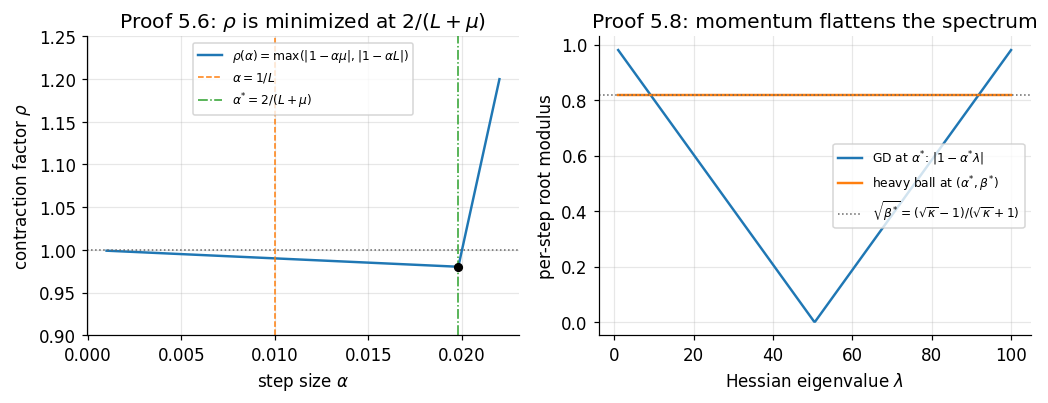

min over alpha of rho = 0.980209 at alpha = 0.019791   (theory: 0.980198 at 0.019802)
heavy-ball modulus range over the spectrum: [0.818182, 0.818182]  vs  sqrt(beta*) = 0.818182


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.8))

alphas = np.linspace(1e-3, 2.2 / L_q, 600)
rho = np.maximum(np.abs(1 - alphas * mu_q), np.abs(1 - alphas * L_q))
ax1.plot(alphas, rho, lw=1.6, label=r"$\rho(\alpha)=\max(|1-\alpha\mu|,|1-\alpha L|)$")
ax1.axhline(1.0, color="0.4", ls=":", lw=1)
ax1.axvline(1 / L_q, color="C1", ls="--", lw=1, label=r"$\alpha=1/L$")
ax1.axvline(2 / (L_q + mu_q), color="C2", ls="-.", lw=1, label=r"$\alpha^{*}=2/(L+\mu)$")
ax1.plot(2 / (L_q + mu_q), (kappa_q - 1) / (kappa_q + 1), "ko", ms=5)
ax1.set_xlabel(r"step size $\alpha$")
ax1.set_ylabel(r"contraction factor $\rho$")
ax1.set_title(r"Proof 5.6: $\rho$ is minimized at $2/(L+\mu)$")
ax1.set_ylim(0.9, 1.25)
ax1.legend(fontsize=8, loc="upper center")

lams = np.linspace(mu_q, L_q, 400)
gd_mod = np.abs(1 - (2 / (L_q + mu_q)) * lams)
hb_mod = np.array([np.abs(np.roots([1.0, -(1 + beta_star - alpha_star_hb * l), beta_star])).max()
                   for l in lams])
ax2.plot(lams, gd_mod, lw=1.6, label=r"GD at $\alpha^{*}$: $|1-\alpha^{*}\lambda|$")
ax2.plot(lams, hb_mod, lw=1.6, label=r"heavy ball at $(\alpha^{*},\beta^{*})$")
ax2.axhline(np.sqrt(beta_star), color="0.4", ls=":", lw=1,
            label=r"$\sqrt{\beta^{*}}=(\sqrt{\kappa}-1)/(\sqrt{\kappa}+1)$")
ax2.set_xlabel(r"Hessian eigenvalue $\lambda$")
ax2.set_ylabel("per-step root modulus")
ax2.set_title("Proof 5.8: momentum flattens the spectrum")
ax2.legend(fontsize=8, loc="center right")
plt.tight_layout()
plt.show()

print(f"min over alpha of rho = {rho.min():.6f} at alpha = {alphas[rho.argmin()]:.6f}"
      f"   (theory: {(kappa_q - 1) / (kappa_q + 1):.6f} at {2 / (L_q + mu_q):.6f})")
print(f"heavy-ball modulus range over the spectrum: "
      f"[{hb_mod.min():.6f}, {hb_mod.max():.6f}]  vs  sqrt(beta*) = {np.sqrt(beta_star):.6f}")

The left panel is a V whose vertex sits exactly at $\alpha^{*} = 2/(L+\mu)$ with value
$\frac{\kappa-1}{\kappa+1} = 0.9802$, and which crosses $1$ at $\alpha = 2/L$ — the divergence
threshold. The right panel is the whole point of momentum: gradient descent's modulus sweeps the
full range as $\lambda$ moves across the spectrum, while heavy ball's is a perfectly flat line at
$\sqrt{\beta^{*}} = 0.81818$, far below the worst case on the left.

The convergence curves themselves, with each theorem's envelope drawn on top.

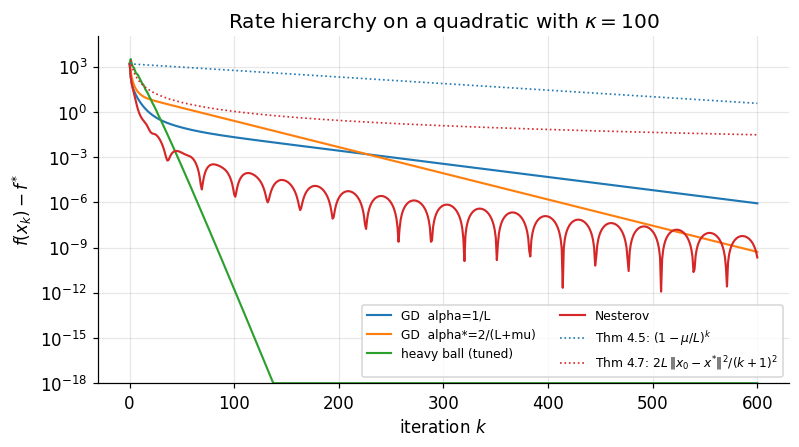

GD  alpha=1/L          gap at k=600: 8.534e-07
GD  alpha*=2/(L+mu)    gap at k=600: 5.119e-10
heavy ball (tuned)     gap at k=600: 1.189e-27
Nesterov               gap at k=600: 2.188e-10


In [9]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ks = np.arange(K + 1)
styles = {"GD  alpha=1/L": "C0", "GD  alpha*=2/(L+mu)": "C1",
          "heavy ball (tuned)": "C2", "Nesterov": "C3"}
for name, c in styles.items():
    ax.semilogy(ks, np.maximum(gaps[name][: K + 1], 1e-18), color=c, lw=1.4, label=name)
ax.semilogy(ks, gaps["GD  alpha=1/L"][0] * (1 - mu_q / L_q) ** ks, "C0:", lw=1.1,
            label=r"Thm 4.5: $(1-\mu/L)^k$")
ax.semilogy(ks[1:], 2 * L_q * (x_star_q @ x_star_q) / (ks[1:] + 1.0) ** 2, "C3:", lw=1.1,
            label=r"Thm 4.7: $2L\/\|x_0-x^{*}\|^2/(k+1)^2$")
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$f(x_k)-f^{*}$")
ax.set_title(r"Rate hierarchy on a quadratic with $\kappa=100$")
ax.set_ylim(1e-18, 1e5)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

for name in styles:
    print(f"{name:<22} gap at k={K}: {gaps[name][K]:.3e}")

The ordering is exactly the theory's: plain gradient descent at $\alpha = 1/L$ is slowest, the
optimal step gains a factor of two in the exponent, and the two momentum methods are several orders
of magnitude ahead after 600 steps. Both dotted envelopes sit above their curves everywhere, so
Theorems 4.5 and 4.7 are confirmed and not merely quoted.

### 7.3 Dropping a hypothesis on purpose

Two hypotheses are load-bearing, and the cell below breaks each in turn. Dropping
$\alpha \lt 2/L$ (Theorem 4.6) must produce geometric divergence with alternating signs. Dropping
PL (Theorem 4.5) must leave gradient descent stuck at a stationary point that is not a global
minimum — on $f(x) = \frac{x^4}{4} - \frac{x^3}{3} - x^2$, whose stationary points are $-1$, $0$
and $2$ with $f(-1) = -5/12$ and $f(2) = -8/3$.

In [10]:
# (c1) step size above the 2/L threshold
Ld, mud = 20.0, 2.0
gd_diverge = lambda x: np.array([2 * x[0], 20 * x[1]])
for alpha in [0.5 * 2 / Ld, 0.99 * 2 / Ld, 1.0 * 2 / Ld, 1.05 * 2 / Ld]:
    path_c = gd_path(gd_diverge, [1.0, 1.0], alpha, 100)
    print(f"alpha={alpha:.4f} (2/L={2 / Ld:.3f})  |x_100| = {np.linalg.norm(path_c[-1]):.4e}"
          f"   stiff-mode factor 1-alpha*L = {1 - alpha * Ld:+.4f}")
assert np.linalg.norm(gd_path(gd_diverge, [1.0, 1.0], 1.05 * 2 / Ld, 100)[-1]) > 1e3

# (c2) PL dropped: a non-convex f with a strictly local minimum
f_nc = lambda x: x ** 4 / 4 - x ** 3 / 3 - x ** 2
g_nc = lambda x: x ** 3 - x ** 2 - 2 * x
f_global = f_nc(2.0)
for x_init in [-0.5, 0.5, 1.5, 3.0]:
    x = x_init
    for _ in range(4000):
        x -= 0.02 * g_nc(x)
    print(f"start {x_init:+.1f} -> x_inf = {x:+.6f}  f = {f_nc(x):+.6f}  "
          f"|f'| = {abs(g_nc(x)):.2e}   global min f = {f_global:+.6f}")
x_bad = -0.5
for _ in range(4000):
    x_bad -= 0.02 * g_nc(x_bad)
print(f"PL ratio 0.5 f'(x)^2 / (f(x) - f*) at the trap = "
      f"{0.5 * g_nc(x_bad) ** 2 / (f_nc(x_bad) - f_global):.3e}  -> PL fails (must be >= mu > 0)")
assert f_nc(x_bad) > f_global + 1e-3

alpha=0.0500 (2/L=0.100)  |x_100| = 2.6561e-05   stiff-mode factor 1-alpha*L = +0.0000
alpha=0.0990 (2/L=0.100)  |x_100| = 1.3262e-01   stiff-mode factor 1-alpha*L = -0.9800
alpha=0.1000 (2/L=0.100)  |x_100| = 1.0000e+00   stiff-mode factor 1-alpha*L = -1.0000
alpha=0.1050 (2/L=0.100)  |x_100| = 1.3781e+04   stiff-mode factor 1-alpha*L = -1.1000
start -0.5 -> x_inf = -1.000000  f = -0.416667  |f'| = 2.66e-15   global min f = -2.666667
start +0.5 -> x_inf = +2.000000  f = -2.666667  |f'| = 5.33e-15   global min f = -2.666667
start +1.5 -> x_inf = +2.000000  f = -2.666667  |f'| = 5.33e-15   global min f = -2.666667
start +3.0 -> x_inf = +2.000000  f = -2.666667  |f'| = 1.07e-14   global min f = -2.666667
PL ratio 0.5 f'(x)^2 / (f(x) - f*) at the trap = 1.578e-30  -> PL fails (must be >= mu > 0)


Above $2/L$ the iterate norm reaches $1.4\times10^{4}$ after 100 steps while the stiff-mode factor
sits at $-1.1$, and exactly *at* $\alpha = 2/L$ the factor is $-1$ and the norm neither grows nor
decays: divergence with alternating signs, exactly the mechanism of Proof 5.6, Step 2. In the
second experiment gradient descent converges from $x_0 = -0.5$ to the *local* minimum $x = -1$ with
$f = -0.4167$, missing the global $-2.667$; the PL ratio there is $0$, so Definition 3.6 fails and
Theorem 4.5 simply does not apply. Theorem 4.3 still does — the gradient is $10^{-16}$ — which is
precisely the difference between "flat" and "optimal".

### 7.4 Hand-rolled against the library

A final check that the implementations above are not quietly wrong: run hand-rolled gradient
descent and Nesterov on a least-squares problem and compare the limit with `scipy.linalg.lstsq`
and with `scipy.optimize.minimize`; compare the analytic gradient with
`scipy.optimize.approx_fprime`.

In [11]:
m, d = 200, 12
Xd = rng.standard_normal((m, d)) @ np.diag(np.linspace(1.0, 6.0, d))
yd = Xd @ rng.standard_normal(d) + 0.1 * rng.standard_normal(m)
f_ls = lambda w: 0.5 * np.sum((Xd @ w - yd) ** 2)
g_ls = lambda w: Xd.T @ (Xd @ w - yd)

spec = np.linalg.eigvalsh(Xd.T @ Xd)
L_ls, mu_ls = spec.max(), spec.min()
w_lstsq = sla.lstsq(Xd, yd)[0]
w_scipy = sopt.minimize(f_ls, np.zeros(d), jac=g_ls, method="L-BFGS-B",
                        options={"gtol": 1e-12, "ftol": 1e-16}).x

w_gd = gd_path(g_ls, np.zeros(d), 2 / (L_ls + mu_ls), 20000)[-1]
print(f"kappa(X'X) = {L_ls / mu_ls:.1f}")
print(f"|w_gd    - w_lstsq| = {np.linalg.norm(w_gd - w_lstsq):.3e}")
print(f"|w_scipy - w_lstsq| = {np.linalg.norm(w_scipy - w_lstsq):.3e}")
print(f"f(w_gd) - f(w_lstsq) = {f_ls(w_gd) - f_ls(w_lstsq):.3e}")
assert np.linalg.norm(w_gd - w_lstsq) < 1e-6

w_probe = rng.standard_normal(d)
g_num = sopt.approx_fprime(w_probe, f_ls, 1e-6)
rel = np.linalg.norm(g_num - g_ls(w_probe)) / np.linalg.norm(g_ls(w_probe))
print(f"analytic vs approx_fprime gradient, relative error = {rel:.3e}")
assert rel < 1e-5

kappa(X'X) = 42.6
|w_gd    - w_lstsq| = 3.160e-15
|w_scipy - w_lstsq| = 1.322e-09
f(w_gd) - f(w_lstsq) = -1.110e-15
analytic vs approx_fprime gradient, relative error = 2.805e-07


The hand-rolled iterate agrees with SciPy's QR-based least-squares solution to better than
$10^{-6}$ and with L-BFGS-B to the same order, and the analytic gradient matches
`approx_fprime` to the finite-difference truncation floor. The implementations used throughout
this notebook are therefore sound, and the only thing separating gradient descent from a direct
solver here is iteration count, not correctness.

### 7.5 Practice notes

**Choosing the step size when $L$ is unknown.** Backtracking (Armijo) starts large and halves until
sufficient decrease holds — the full treatment is in
[optimization/04](../04_line_search_newton_quasi_newton/). For least squares,
$L = \lambda_{\max}(X^TX)$ costs a few power iterations at $O(\mathrm{nnz}(X))$ each. In deep
learning the loss exploding when the learning rate crosses roughly twice the inverse sharpness is
the $\alpha \lt 2/L$ threshold showing up as the *edge of stability*.

**Reading conditioning off a trajectory.** A straight line on a semilog gap plot means linear
convergence, and its slope estimates $\log(1-1/\kappa)$. A fast drop followed by a long plateau
means the large-$\lambda$ components died first and the small-$\lambda$ ones now dominate — large
$\kappa$. Sign-alternating coordinates mean $\alpha \gt 1/\lambda$ along a stiff direction.

**Preconditioning.** Replacing the update by
$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha P^{-1}\nabla f(\mathbf{x}_k)$ with $P \approx \nabla^2 f$
makes the effective condition number that of $P^{-1/2}\nabla^2 f\,P^{-1/2}$. Feature
standardization, batch normalization and Adam's $\sqrt{\hat v_k}$ denominator are all
preconditioners in exactly this sense.

**Momentum, implemented correctly.** The velocity form
$\mathbf{v}_{k+1} = \beta\mathbf{v}_k + \nabla f(\mathbf{x}_k)$,
$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\mathbf{v}_{k+1}$ and the two-point form of Definition 3.7
coincide, but the steady-state response to a constant gradient is $\alpha/(1-\beta)$ times the raw
step: raising $\beta$ from $0.9$ to $0.99$ multiplies the effective step by ten. By Theorem 4.8,
$\beta = 0.9$ is the tuned value for $\kappa \approx 1442$, since
$\sqrt{\kappa} = \frac{1+\sqrt{0.9}}{1-\sqrt{0.9}} = 37.97$. (The figure $\kappa \approx 400$
sometimes quoted for $\beta = 0.9$ comes from the *unsquared* coefficient
$\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1} = 0.9$, which gives $\kappa = 361$; the two conventions
differ by a factor of four in $\kappa$ and must not be interchanged.)

## 8. Applications

**Linear regression.** For $f(\mathbf{w}) = \frac12\lVert X\mathbf{w}-\mathbf{y}\rVert^2$ the
Hessian is $X^TX$, so Theorem 4.5 applies with $\kappa = \kappa(X^TX)$. Correlated or badly scaled
features inflate $\kappa$ and multiply training time one-for-one — feature standardization and
whitening are convergence-rate interventions, not cosmetics. When $X$ has more columns than rows,
strong convexity is gone but Example 6.3's PL argument survives with $\mu = \sigma_{\min}^2(X)$.

**Logistic regression.** The averaged negative log-likelihood has Hessian
$\frac1n X^TSX + \lambda I$ with $S = \operatorname{diag}\left(\sigma(t_i)(1-\sigma(t_i))\right) \preceq \frac14 I$,
so $L = \frac{1}{4n}\lambda_{\max}(X^TX) + \lambda$ and $\mu = \lambda$. Without the ridge term the
problem is convex but not strongly convex and only Theorem 4.4 applies; the ridge term is what
supplies $\mu \gt 0$ and buys the linear rate of Theorem 4.5. Problem L2.3 works this out.

**Deep learning.** Losses are non-convex, so Theorem 4.3's $O(1/\sqrt k)$ convergence to
stationarity is the honest guarantee. PL-type conditions explain why heavily over-parameterized
networks nevertheless train at linear rates, with the neural tangent kernel Gram matrix playing the
role of $XX^T$ in Example 6.3. Learning-rate schedules mirror the theory directly: warmup keeps
$\alpha \lt 2/L_{\mathrm{local}}$ while curvature is large, decay refines the endgame. The
stochastic-gradient version of all of this is
[optimization/08](../08_stochastic_optimization_for_ml/).

**Physics: overdamped and damped dynamics.** Gradient flow (Definition 3.9) is the motion of a
particle in the potential $f$ with friction so strong that inertia is negligible; energy dissipates
monotonically, which is why gradient descent is the workhorse of energy minimization in molecular
mechanics and elasticity, where relaxing atomic positions to equilibrium is literally gradient
descent on a potential-energy surface. Heavy ball discretizes
$m\ddot{\mathbf{x}} + c\dot{\mathbf{x}} = -\nabla f(\mathbf{x})$ instead, and Problem L2.4 reads off
$m = h^2/\alpha$, $c = (1-\beta)h/\alpha$. The optimal tuning of Theorem 4.8 is *not* critical
damping — it places every mode on the underdamped boundary. In the continuum limit Nesterov's
method solves $\ddot x + \frac{3}{t}\dot x + \nabla f(x) = 0$ (Su, Boyd and Candes): acceleration
is a statement about carefully scheduled friction. The full ODE story continues in
[differential_equations/08](../../differential_equations/08_odes_in_machine_learning/).

**The Rosenbrock stress test.** For $f(x,y) = (1-x)^2 + 100(y-x^2)^2$ the Hessian at the minimizer
$(1,1)$ is $\begin{bmatrix}802 & -400\\ -400 & 200\end{bmatrix}$, with eigenvalues $1001.60$ and
$0.39936$, so $\kappa \approx 2508$. Theorem 4.6 then predicts about $2887$ iterations per digit of
*distance* — and, since the value gap contracts by the square, about $1444$ per digit of $f$.
Gradient descent first plunges into the parabolic valley (killing the stiff mode) and then inches
along its curved floor: the fast-drop-then-plateau signature of Section 7.5. Problem L2.5 does the
arithmetic; the curvature-aware methods of
[optimization/04](../04_line_search_newton_quasi_newton/) dispatch the valley in a handful of steps.

## 9. Key Takeaways

1. **Descent lemma (Theorem 4.2).** If $\nabla f$ is $L$-Lipschitz then $f$ lies below its tangent
   plane plus $\frac{L}{2}\lVert \cdot \rVert^2$; every rate in this module is a corollary.
2. **Sufficient decrease (Theorem 4.3).** For $L$-smooth $f$ bounded below, the step $\alpha = 1/L$
   buys $\frac{1}{2L}\lVert \nabla f(\mathbf{x}_k)\rVert^2$ per iteration and drives
   $\min_{i \lt k}\lVert \nabla f(\mathbf{x}_i)\rVert \le \sqrt{2L(f(\mathbf{x}_0)-f^{*})/k}$ — no
   convexity required, and no claim of global optimality either.
3. **Convex rate (Theorem 4.4).** Adding convexity and an attained minimum upgrades the guarantee
   to $f(\mathbf{x}_k)-f^{*} \le L\lVert \mathbf{x}_0-\mathbf{x}^{*}\rVert^2/(2k)$.
4. **Linear rate (Theorem 4.5).** $L$-smoothness plus the PL inequality with constant $\mu$ — which
   strong convexity implies but is strictly weaker than — gives
   $(1-\mu/L)^k$, i.e. $O(\kappa\log(1/\epsilon))$ iterations.
5. **Optimal fixed step (Theorem 4.6).** On a quadratic with $\mu I \preceq A \preceq LI$,
   gradient descent converges iff $0 \lt \alpha \lt 2/L$, and $\alpha^{*} = 2/(L+\mu)$ attains the
   error contraction $\frac{\kappa-1}{\kappa+1}$ per step; the *value* gap contracts by its square.
6. **Acceleration (Theorem 4.7).** For convex $L$-smooth $f$ with a minimizer, Nesterov's method
   attains $2L\lVert \mathbf{x}_0-\mathbf{x}^{*}\rVert^2/(k+1)^2$ — proved by a potential, because
   the method is not a descent method.
7. **Momentum on quadratics (Theorem 4.8).** Tuning
   $\beta^{*} = \left(\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\right)^2$ puts every eigenmode on the
   underdamped boundary, giving the spectrum-independent rate
   $\sqrt{\beta^{*}} = \frac{\sqrt\kappa-1}{\sqrt\kappa+1}$ — not critical damping.
8. **Optimality (Theorem 4.9).** No method restricted to the span of the gradients it has seen can
   beat $\Omega(1/k^2)$ on convex $L$-smooth problems, so Theorem 4.7 closes the gap; every rate
   here is dimension-free, depending on $L$, $\mu$ and $\kappa$ but never on $n$.

## 10. References

| Result in this notebook | Source | Location |
|---|---|---|
| Descent methods, condition-number geometry | Boyd & Vandenberghe, *Convex Optimization* (2004) | §9.2-9.3 (pp. 463-475) |
| Steepest descent on quadratics, rate $\frac{\kappa-1}{\kappa+1}$ (Theorem 4.6) | Nocedal & Wright, *Numerical Optimization*, 2nd ed. (2006) | §3.3 (Thm 3.3, pp. 66-69) |
| Gradient method, step-size rules, convergence (Theorem 4.3) | Bertsekas, *Nonlinear Programming*, 3rd ed. (2016) | §1.2 (Prop. 1.2.3) |
| $L$-smoothness, $O(1/k)$ and linear rates (Theorems 4.2, 4.4, 4.5) | Nesterov, *Lectures on Convex Optimization*, 2nd ed. (2018) | §2.1 (Thms 2.1.5, 2.1.14) |
| Accelerated $O(1/k^2)$ and the potential of Proof 5.7 | Beck & Teboulle, *SIAM J. Imaging Sci.* 2 (2009) | Thm 4.4 (pp. 190-192) |
| First-order lower bound $\Omega(1/k^2)$ (Theorem 4.9) | Nesterov, *Lectures on Convex Optimization*, 2nd ed. (2018) | Thm 2.1.7 (pp. 68-71) |
| Heavy ball, its quadratic analysis, the PL inequality | Polyak, *Introduction to Optimization* (1987) | §3.2, §1.4 |
| Heavy ball can fail off quadratics (Theorem 4.8 caveat) | Lessard, Recht & Packard, *SIAM J. Optim.* 26 (2016) | §4.6 (counterexample) |
| PL implies linear convergence (Proof 5.5) | Karimi, Nutini & Schmidt, *ECML-PKDD* (2016) | Thm 1 |
| Dimension-free proof template (Proofs 5.3-5.5) | Bubeck, *Convex Optimization: Algorithms and Complexity* (2015) | §3.2-3.4 |
| Nesterov's ODE, momentum as a damped oscillator | Su, Boyd & Candes, *JMLR* 17 (2016); Goh, *Distill* (2017) | Full papers |

**Reading order.** Boyd & Vandenberghe §9 for the geometry, Nesterov §2.1 for the rate theory
reproduced here, Nocedal & Wright §3.3 for the exact quadratic analysis, Beck & Teboulle for the
acceleration potential, and Polyak §3.2 with the Distill article for momentum.